Starting network comparison analysis...
Loading original network data...
Loaded 849981 edges and 32272 nodes for original network
Creating original graph...
Original graph: 32272 nodes, 849981 edges
Loading normal size model data...
Loaded 1011690 edges and 32272 nodes for normal size model
Creating normal size graph...
Normal size graph: 32272 nodes, 1011690 edges
Loading half size model data...
Loaded 251728 edges and 16123 nodes for half size model
Creating half size graph...
Half size graph: 16123 nodes, 251728 edges
Loading double size model data...


/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


Loaded 4046760 edges and 64544 nodes for double size model
Creating double size graph...
Double size graph: 93675 nodes, 4046760 edges
Loading quad size model data...
Loaded 16187040 edges and 129088 nodes for quad size model
Creating quad size graph...
Quad size graph: 160366 nodes, 16187040 edges
Successfully loaded 5 graphs for comparison
Plotting in-degree distributions...
Saved in-degree distribution comparison plot
Plotting out-degree distributions...
Saved out-degree distribution comparison plot
Plotting cumulative in-degree distributions...
Saved cumulative in-degree distribution comparison plot
Plotting cumulative out-degree distributions...
Saved cumulative out-degree distribution comparison plot
Calculating directed clustering coefficients...
Calculating directed clustering for Original Network network...
Sampled 1000 nodes for clustering calculation
Original Network network average directed clustering: 0.0190
Calculating directed clustering for SBM + Clustering network...
S

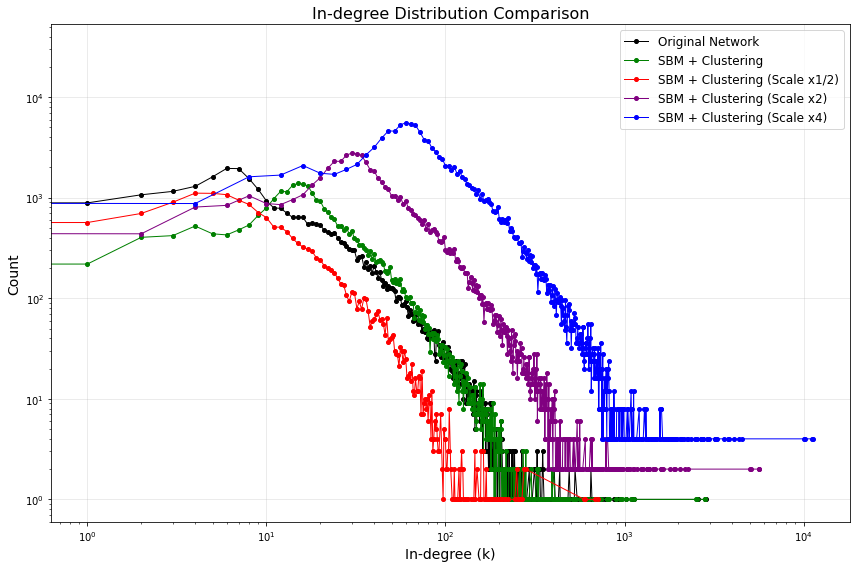

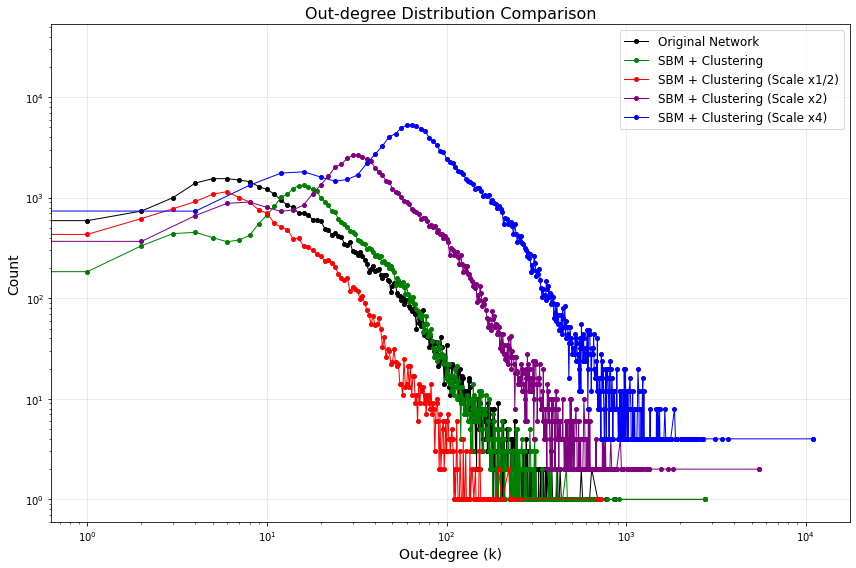

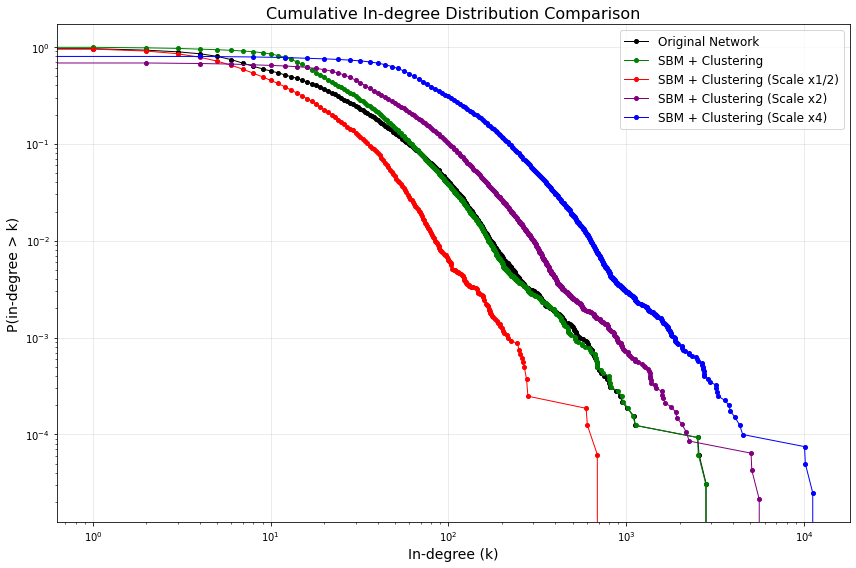

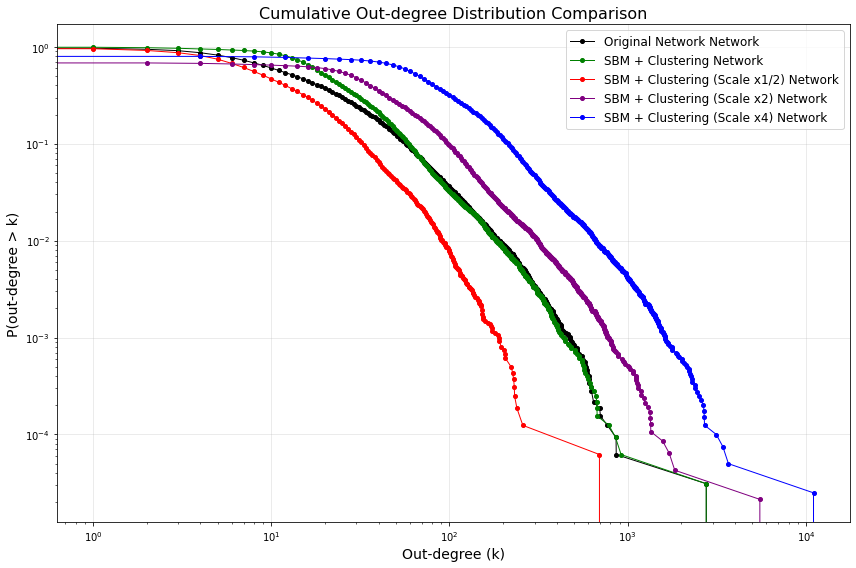

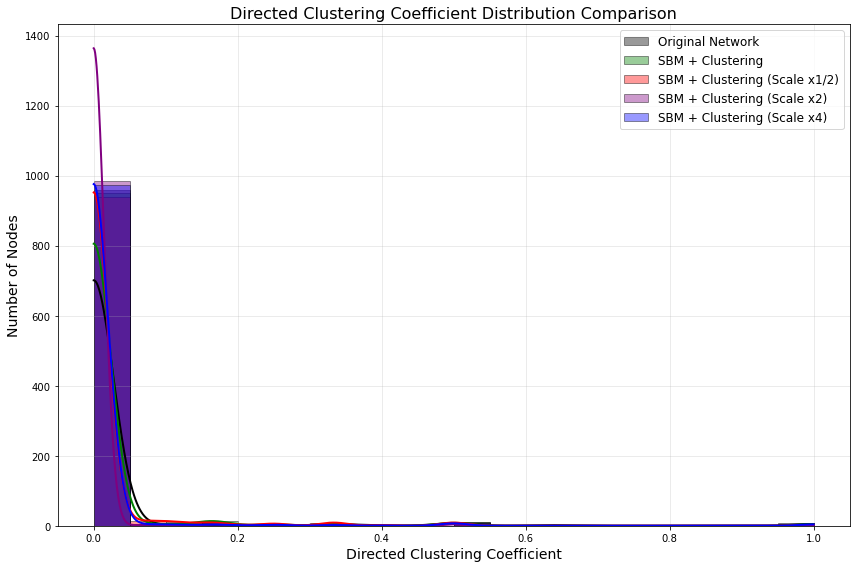

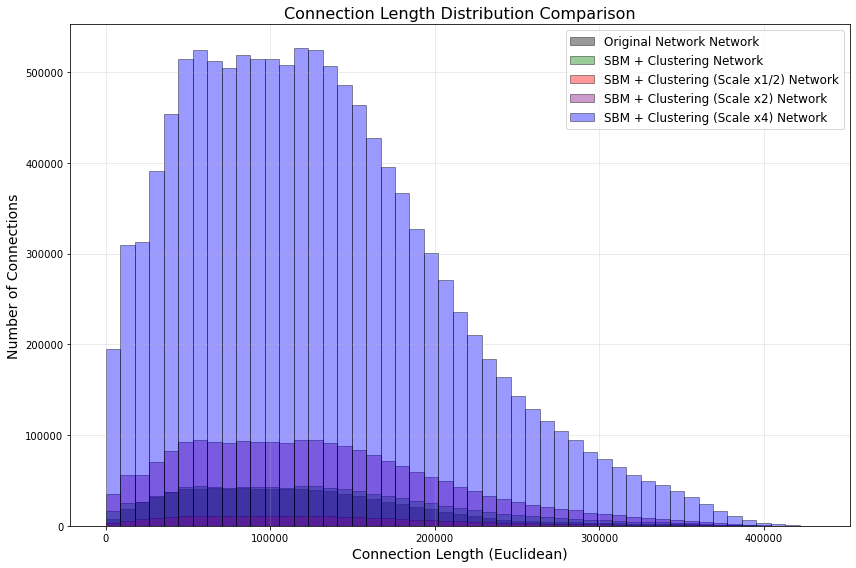

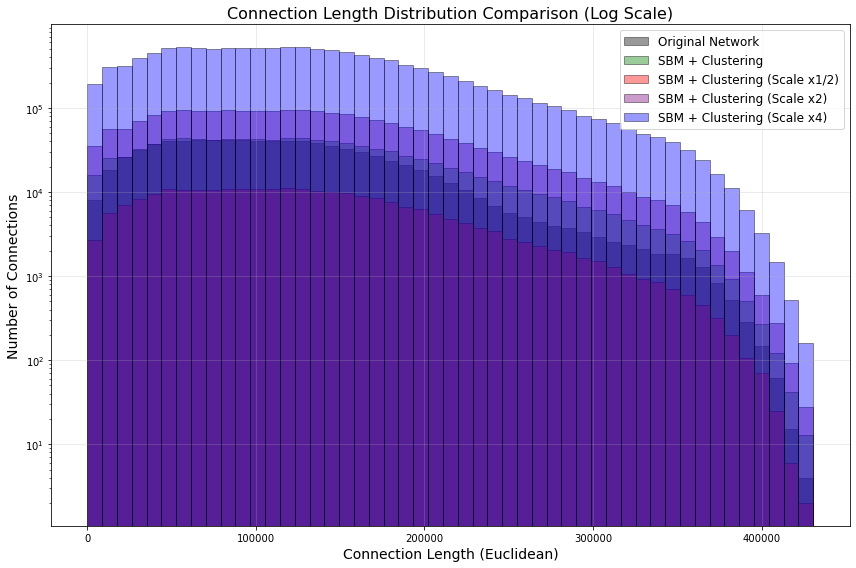

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde

print("Starting network comparison analysis...")

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Function to calculate Euclidean distance
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Load original network data
print("Loading original network data...")
try:
    edges_df = pd.read_csv("fly_edges.csv")
    metadata_df = pd.read_csv("fly_metadata.csv")
    print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes for original network")
    
    # Create original graph
    print("Creating original graph...")
    G_original = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in metadata_df.iterrows():
        node_id = node_data['node_id']
        G_original.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in edges_df.iterrows():
        G_original.add_edge(edge['from'], edge['to'])
    
    print(f"Original graph: {G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading original network: {e}")
    G_original = None

# Load normal size model
print("Loading normal size model data...")
try:
    normal_edges_df = pd.read_csv("bcnm_edges.csv")
    normal_metadata_df = pd.read_csv("bcnm_metadata.csv")
    print(f"Loaded {len(normal_edges_df)} edges and {len(normal_metadata_df)} nodes for normal size model")
    
    # Create normal size graph
    print("Creating normal size graph...")
    G_normal = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in normal_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_normal.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in normal_edges_df.iterrows():
        G_normal.add_edge(edge['from'], edge['to'])
    
    print(f"Normal size graph: {G_normal.number_of_nodes()} nodes, {G_normal.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading normal size model: {e}")
    G_normal = None

# Load half size model
print("Loading half size model data...")
try:
    half_edges_df = pd.read_csv("half_size_bcnm_edges.csv")
    half_metadata_df = pd.read_csv("half_size_bcnm_metadata.csv")
    print(f"Loaded {len(half_edges_df)} edges and {len(half_metadata_df)} nodes for half size model")
    
    # Create half size graph
    print("Creating half size graph...")
    G_half = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in half_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_half.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in half_edges_df.iterrows():
        G_half.add_edge(edge['from'], edge['to'])
    
    print(f"Half size graph: {G_half.number_of_nodes()} nodes, {G_half.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading half size model: {e}")
    G_half = None

# Load double size model
print("Loading double size model data...")
try:
    double_edges_df = pd.read_csv("double_size_bcnm_edges.csv")
    double_metadata_df = pd.read_csv("double_size_bcnm_metadata.csv")
    print(f"Loaded {len(double_edges_df)} edges and {len(double_metadata_df)} nodes for double size model")
    
    # Create double size graph
    print("Creating double size graph...")
    G_double = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in double_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_double.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in double_edges_df.iterrows():
        G_double.add_edge(edge['from'], edge['to'])
    
    print(f"Double size graph: {G_double.number_of_nodes()} nodes, {G_double.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading double size model: {e}")
    G_double = None
    
# Load quad size model
print("Loading quad size model data...")
try:
    double_edges_df = pd.read_csv("quad_size_bcnm_edges.csv")
    double_metadata_df = pd.read_csv("quad_size_bcnm_metadata.csv")
    print(f"Loaded {len(double_edges_df)} edges and {len(double_metadata_df)} nodes for quad size model")
    
    # Create double size graph
    print("Creating quad size graph...")
    G_quad = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in double_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_quad.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in double_edges_df.iterrows():
        G_quad.add_edge(edge['from'], edge['to'])
    
    print(f"Quad size graph: {G_quad.number_of_nodes()} nodes, {G_quad.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading double size model: {e}")
    G_double = None


# Create a list of valid graphs and their labels
graphs = []
labels = []

if G_original is not None:
    graphs.append(G_original)
    labels.append("Original Network")
if G_normal is not None:
    graphs.append(G_normal)
    labels.append("SBM + Clustering")
if G_half is not None:
    graphs.append(G_half)
    labels.append("SBM + Clustering (Scale x1/2)")
if G_double is not None:
    graphs.append(G_double)
    labels.append("SBM + Clustering (Scale x2)")
if G_quad is not None:
    graphs.append(G_quad)
    labels.append("SBM + Clustering (Scale x4)")

print(f"Successfully loaded {len(graphs)} graphs for comparison")

if len(graphs) == 0:
    print("No valid graphs found. Please check the input files.")
    exit()

# Define colors for each graph
colors = ['black', 'green', 'red', 'purple','blue']
colors = colors[:len(graphs)]  # Slice to match number of graphs

# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    plt.loglog(
        sorted(in_degree_counts.keys()),
        [in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot")

# Plot out-degree distributions
print("Plotting out-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    plt.loglog(
        sorted(out_degree_counts.keys()),
        [out_degree_counts[k] for k in sorted(out_degree_counts.keys())],
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot")

# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

# Plot cumulative out-degree distributions
print("Plotting cumulative out-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    sorted_degrees = sorted(out_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot")

# Define directed clustering coefficient function
def directed_clustering_coefficient(G):
    """Calculate directed clustering coefficient for each node in the graph."""
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        preds = set(G.predecessors(node))
        succs = set(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0 or undefined (we'll use 0)
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in preds:
            for succ in succs:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Calculate and plot clustering coefficients
print("Calculating directed clustering coefficients...")
clustering_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating directed clustering for {label} network...")
    # Sample nodes for large networks to speed up calculation
    if G.number_of_nodes() > 1000:
        sample_nodes = random.sample(list(G.nodes()), 1000)
        subgraph = G.subgraph(sample_nodes)
        clustering = directed_clustering_coefficient(subgraph)
        print(f"Sampled {len(sample_nodes)} nodes for clustering calculation")
    else:
        clustering = directed_clustering_coefficient(G)
    
    clustering_data[label] = list(clustering.values())
    print(f"{label} network average directed clustering: {np.mean(list(clustering.values())):.4f}")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

for i, label in enumerate(labels):
    values = clustering_data[label]
    plt.hist(
        values,
        bins=bins,
        alpha=0.4,
        color=colors[i],
        edgecolor='black',
        label=f"{label}"
    )
    
    # Add kernel density estimation if there are enough values
    if len(values) > 10:
        kde = gaussian_kde(values)
        x_vals = np.linspace(0, 1, 1000)
        plt.plot(
            x_vals,
            kde(x_vals) * len(values) * (bins[1] - bins[0]),
            linewidth=2,
            color=colors[i]
        )

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_directed_clustering_coefficient.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot")

# Calculate and plot connection distances
print("Calculating connection distances...")
distance_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating distances for {label} network...")
    # Use all edges for the distance calculation as requested
    print(f"Processing all {G.number_of_edges()} edges for distance calculation")
    
    distances = []
    for edge in G.edges():
        distance = calculate_euclidean_distance(G, edge)
        if distance is not None:
            distances.append(distance)
    
    distance_data[label] = distances
    print(f"{label} network: {len(distances)} distances calculated, avg = {np.mean(distances):.4f}")

# Plot connection distance distributions
print("Plotting connection distance distributions...")
plt.figure(figsize=(12, 8))

max_distance = max([max(distances) for distances in distance_data.values() if distances])
bins = np.linspace(0, max_distance, 50)

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=0.4,
            color=colors[i],
            edgecolor='black',
            label=f"{label} Network"
        )

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot")

# Plot connection distance distributions with log scale
print("Plotting connection distance distributions with log scale...")
plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=0.4,
            color=colors[i],
            edgecolor='black',
            label=f"{label}"
        )

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot")

# Generate a summary table
print("Generating network comparison summary...")
summary_data = {
    'Network': labels,
    'Nodes': [G.number_of_nodes() for G in graphs],
    'Edges': [G.number_of_edges() for G in graphs],
    'Avg In-Degree': [np.mean([d for _, d in G.in_degree()]) for G in graphs],
    'Avg Out-Degree': [np.mean([d for _, d in G.out_degree()]) for G in graphs],
    'Max In-Degree': [max([d for _, d in G.in_degree()]) for G in graphs],
    'Max Out-Degree': [max([d for _, d in G.out_degree()]) for G in graphs],
    'Avg Directed Clustering': [np.mean(clustering_data[label]) for label in labels],
    'Avg Connection Length': [np.mean(distance_data[label]) if distance_data[label] else np.nan for label in labels],
    'Min Connection Length': [min(distance_data[label]) if distance_data[label] else np.nan for label in labels],
    'Max Connection Length': [max(distance_data[label]) if distance_data[label] else np.nan for label in labels],
}

summary_df = pd.DataFrame(summary_data)
print("\nNetwork Comparison Summary:")
print(summary_df)

# Save summary to CSV
summary_df.to_csv('network_comparison_summary.csv', index=False)
print("Saved network comparison summary to CSV")

print("Network comparison analysis complete!")

In [2]:
# Define colors for each graph
colors = ['black', 'red', 'green', 'blue','purple']
colors = colors[:len(graphs)]  # Slice to match number of graphs
# Plot in-degree distributions

Plotting in-degree distributions...
Saved in-degree distribution comparison plot


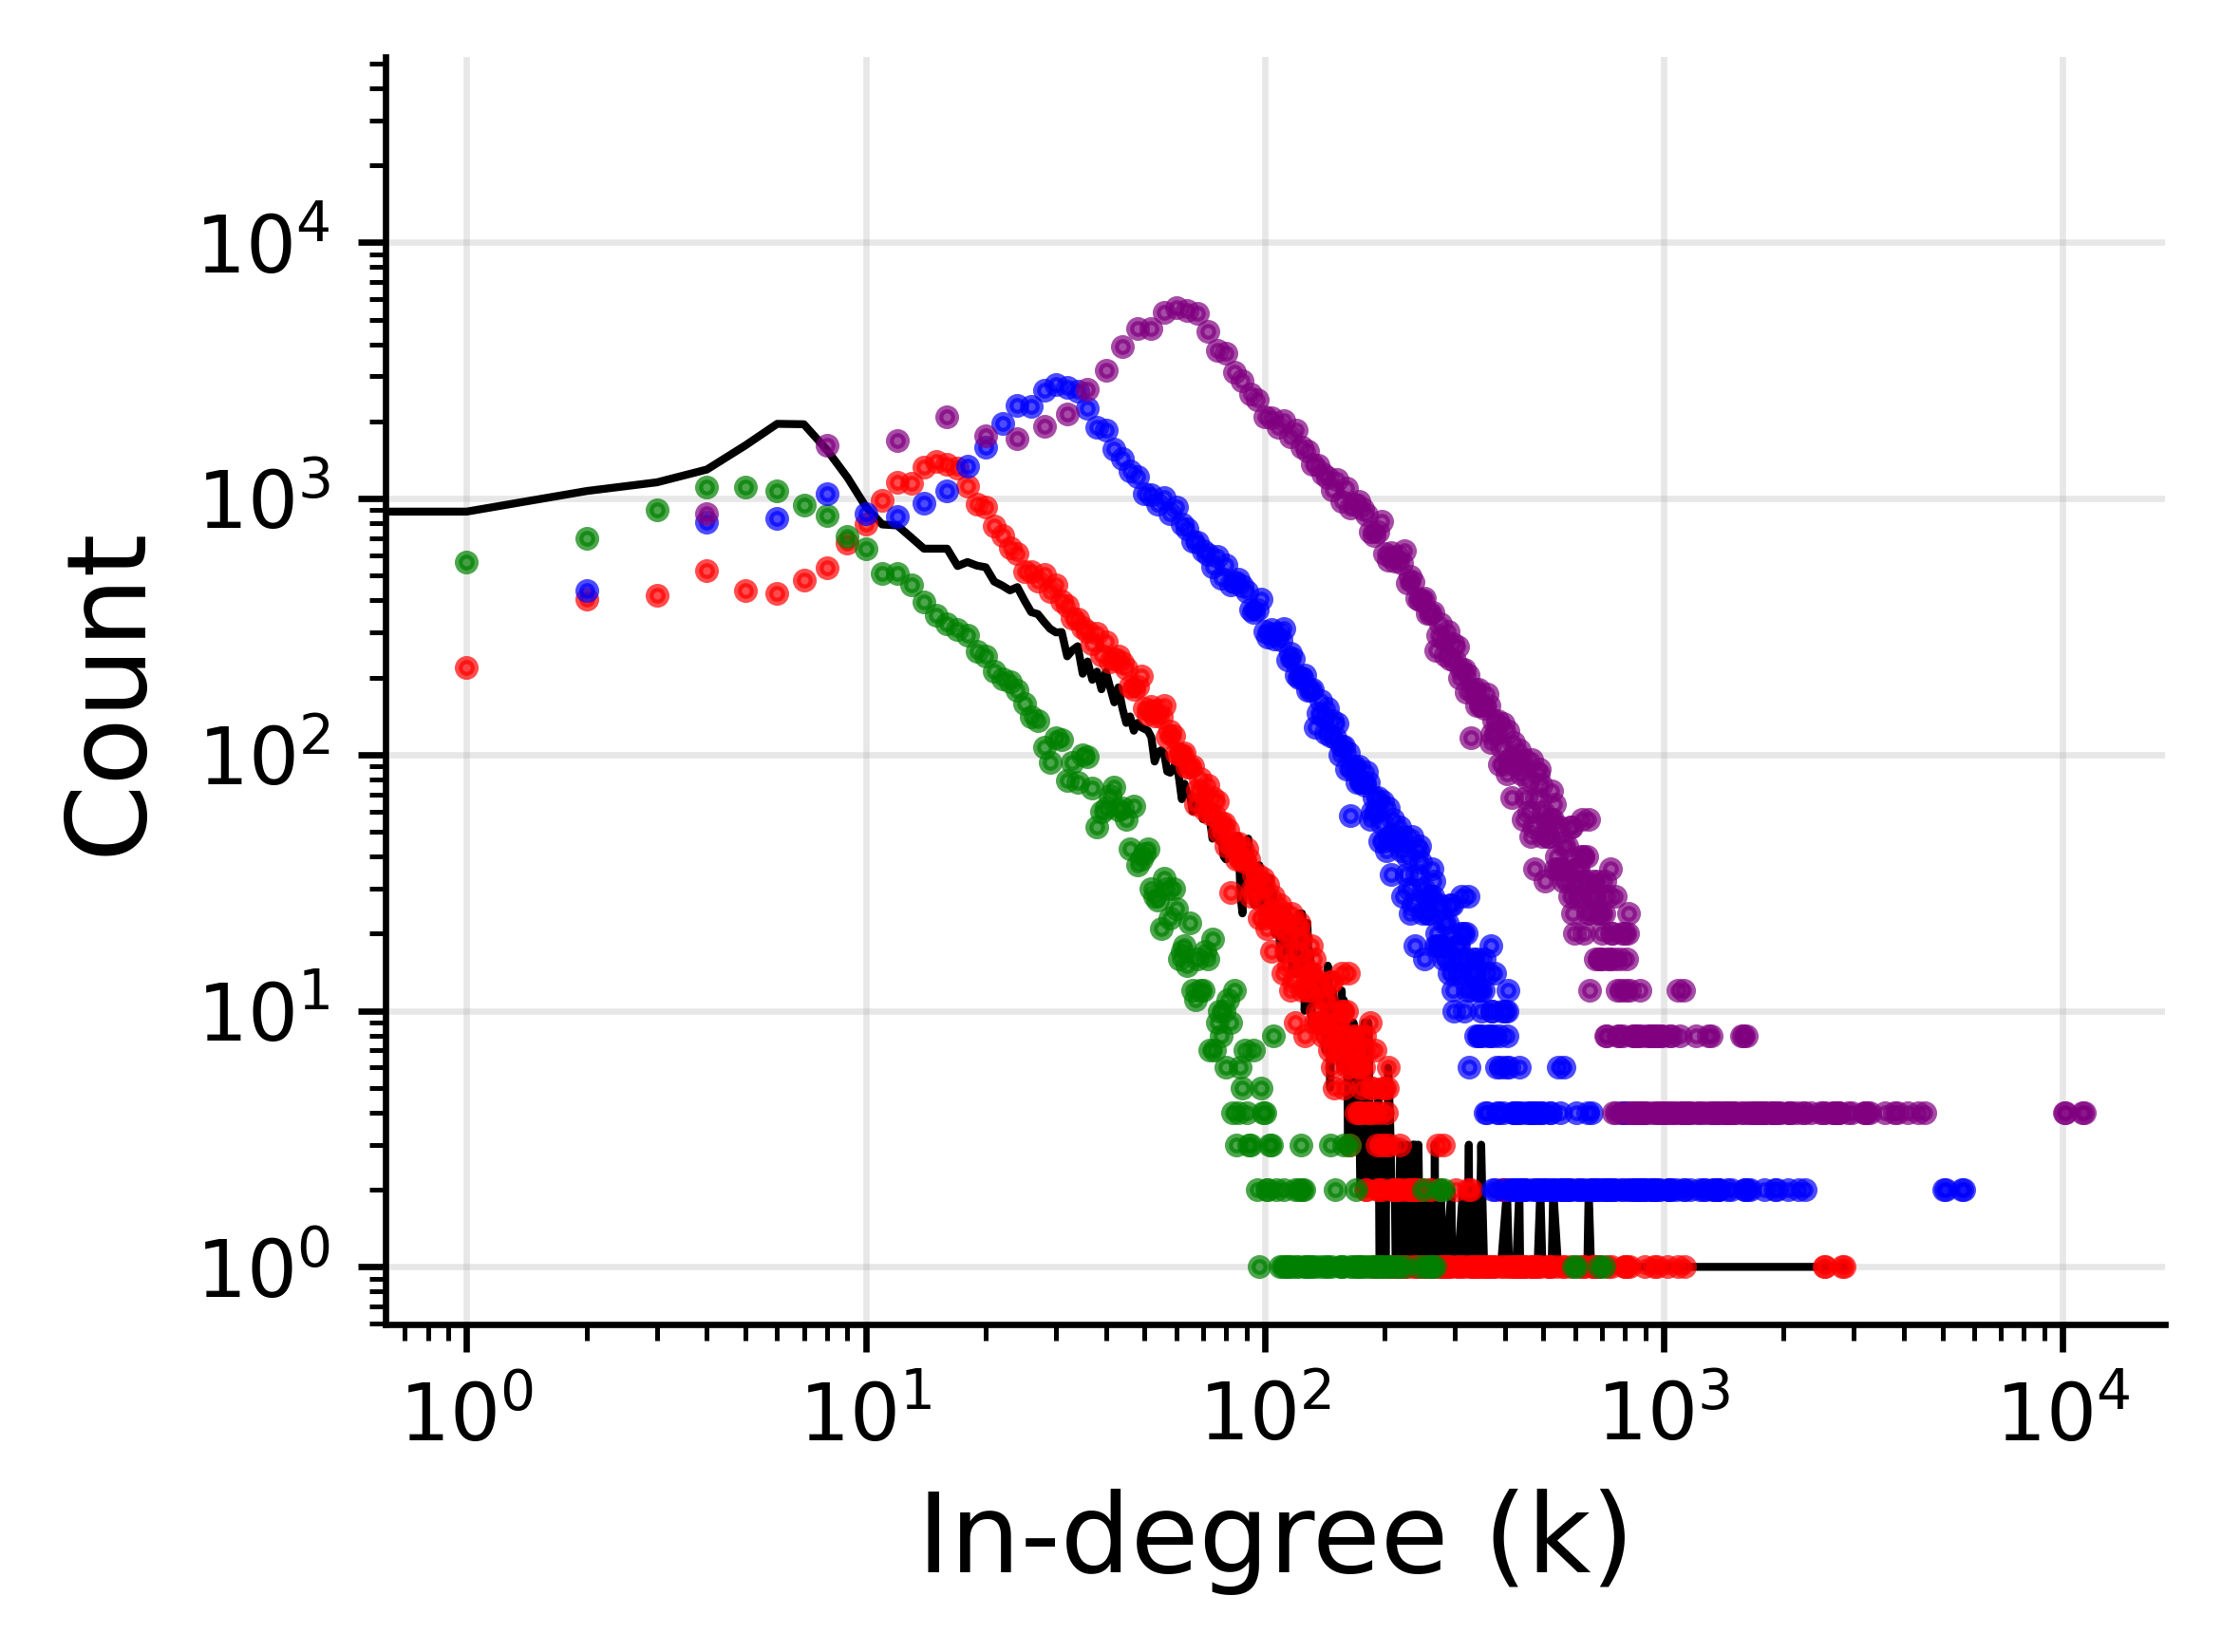

In [3]:
# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    
    # Set linewidth to 1 for original network only, 0 for others
    lw = 1 if label == "Original Network" else 0
    ms = 0 if label == "Original Network" else 4
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        sorted(in_degree_counts.keys()),
        [in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
        marker='.',
        markersize=ms,
        linewidth=lw,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
# plt.title('In-degree Distribution Comparison', fontsize=16)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_in_degree_distribution.pdf')
print("Saved in-degree distribution comparison plot")

Plotting in-degree distributions...
Saved in-degree distribution comparison plot


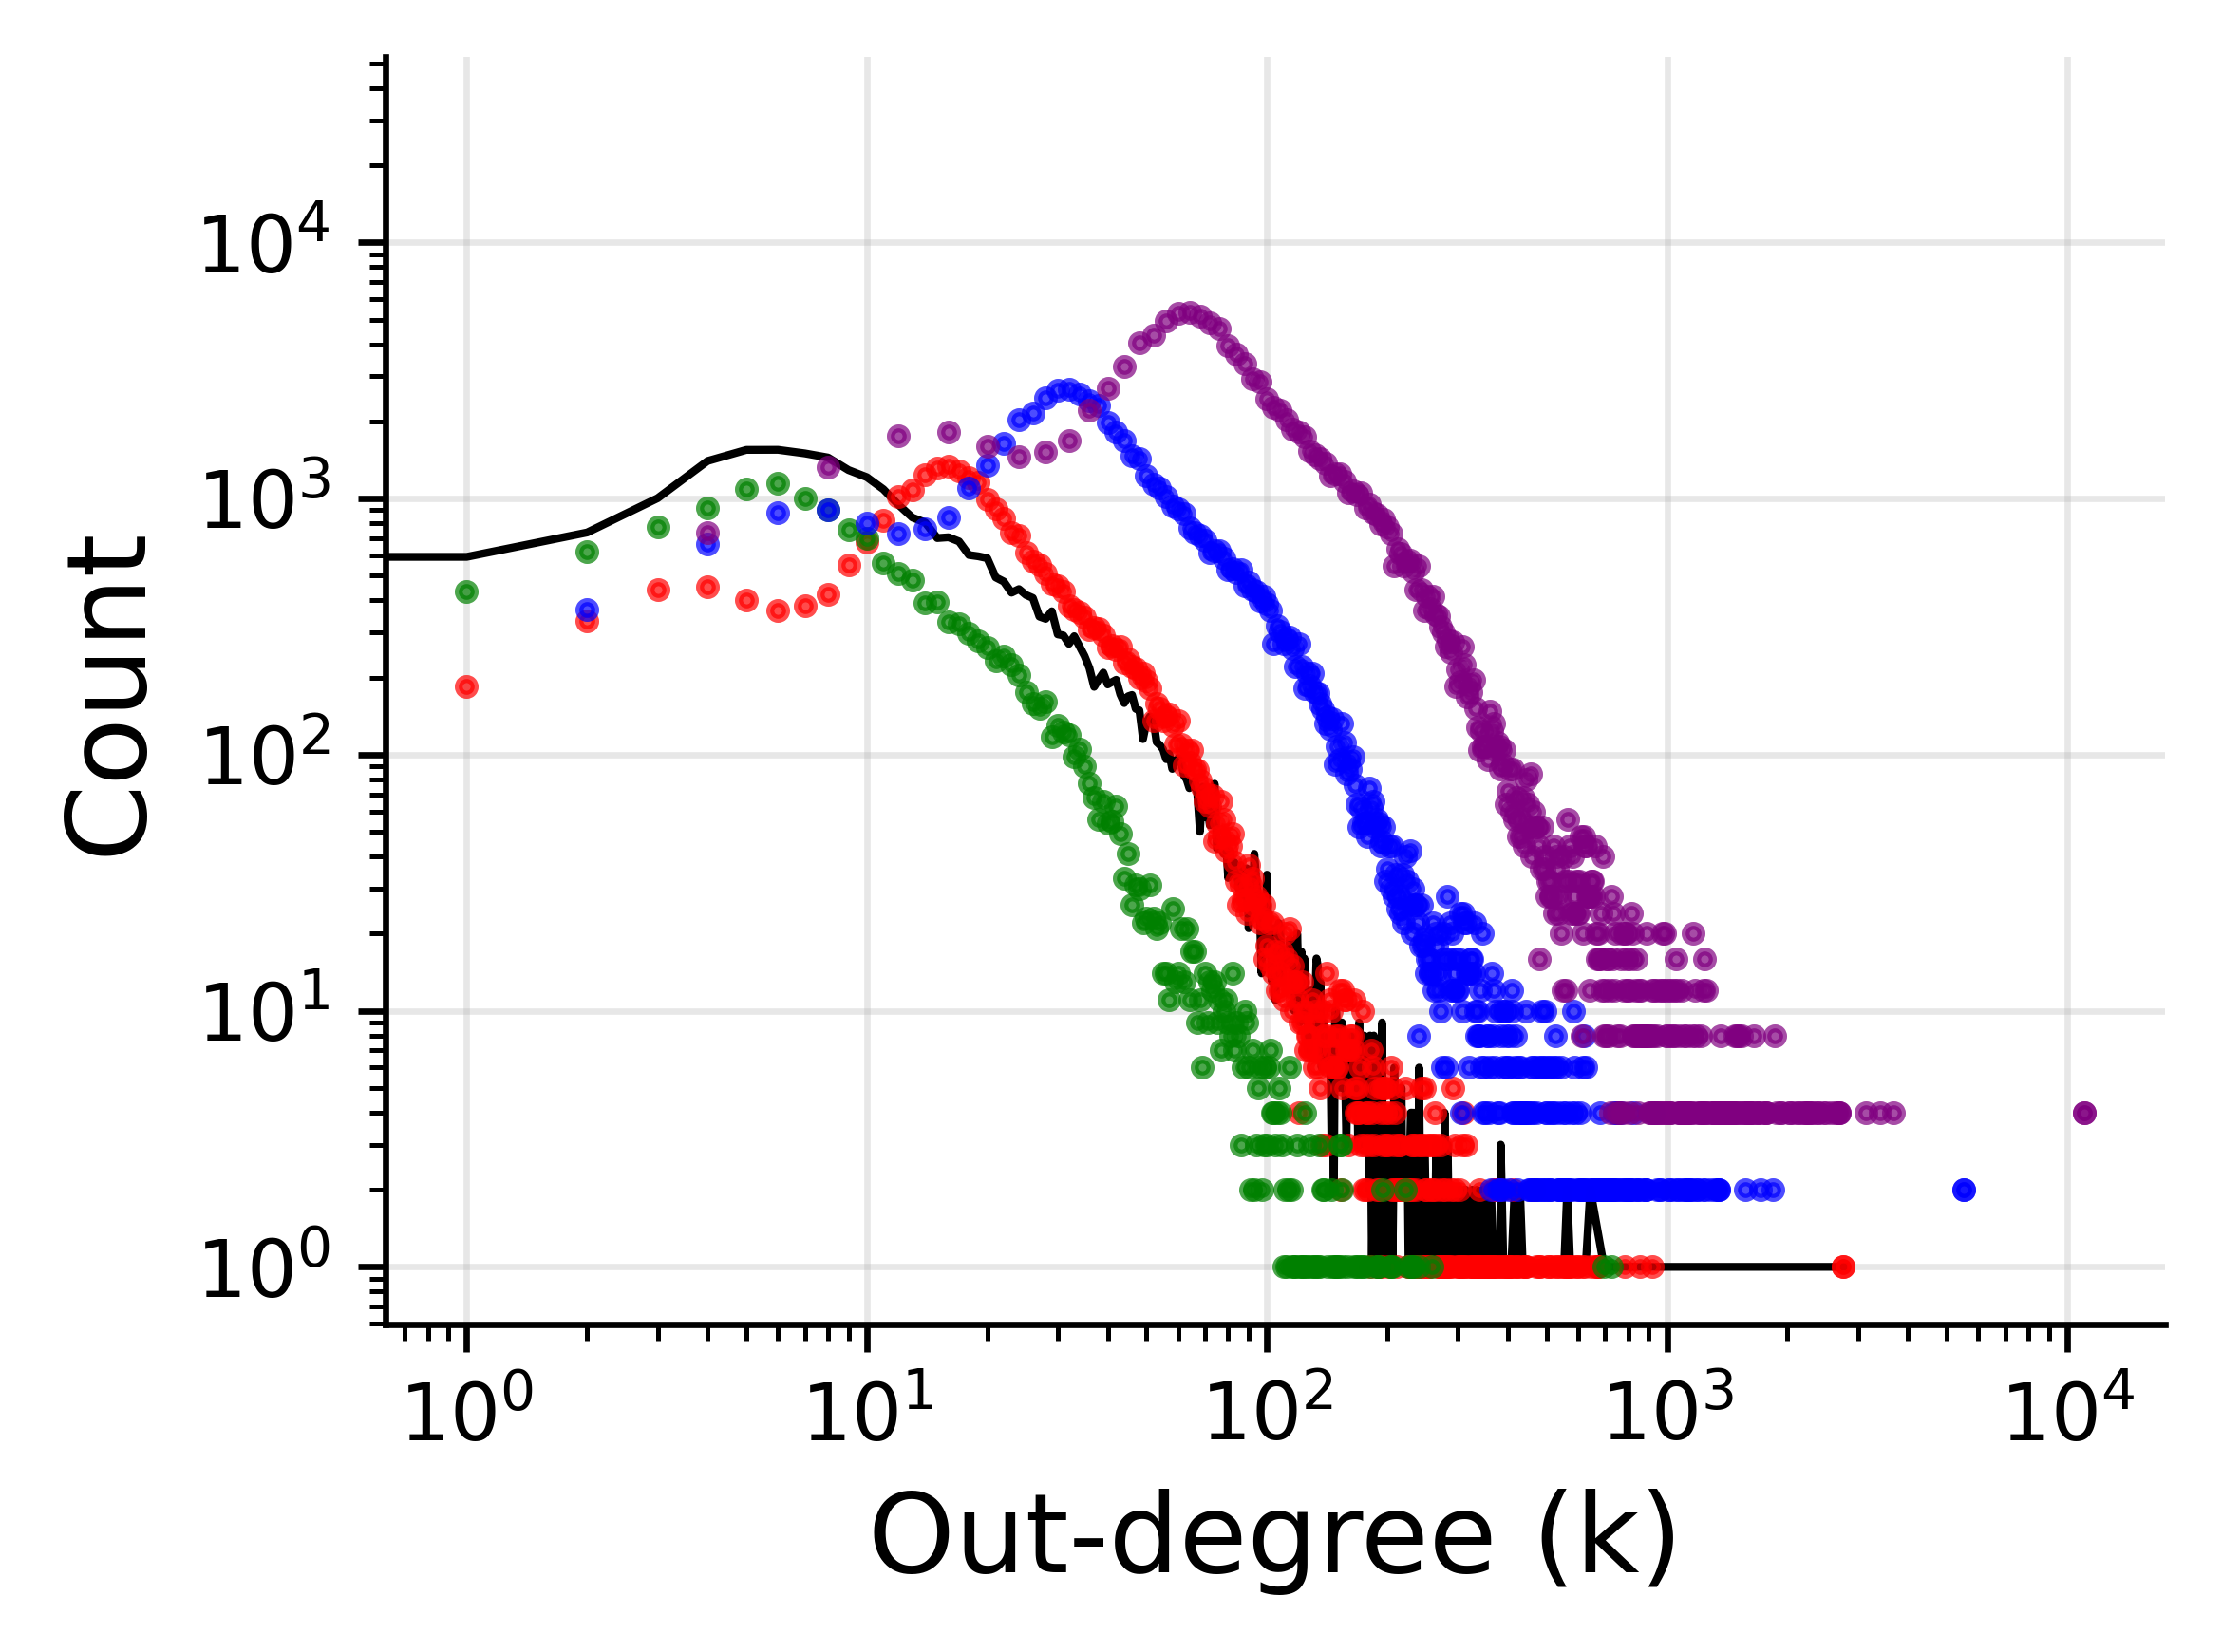

In [4]:
# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    
    # Set linewidth to 1 for original network only, 0 for others
    lw = 1 if label == "Original Network" else 0
    ms = 0 if label == "Original Network" else 4
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        sorted(out_degree_counts.keys()),
        [out_degree_counts[k] for k in sorted(out_degree_counts.keys())],
        marker='.',
        markersize=ms,
        linewidth=lw,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
# plt.title('In-degree Distribution Comparison', fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_out_degree_distribution.pdf', dpi=600)
print("Saved in-degree distribution comparison plot")

Plotting cumulative in-degree distributions...
Saved cumulative in-degree distribution comparison plot


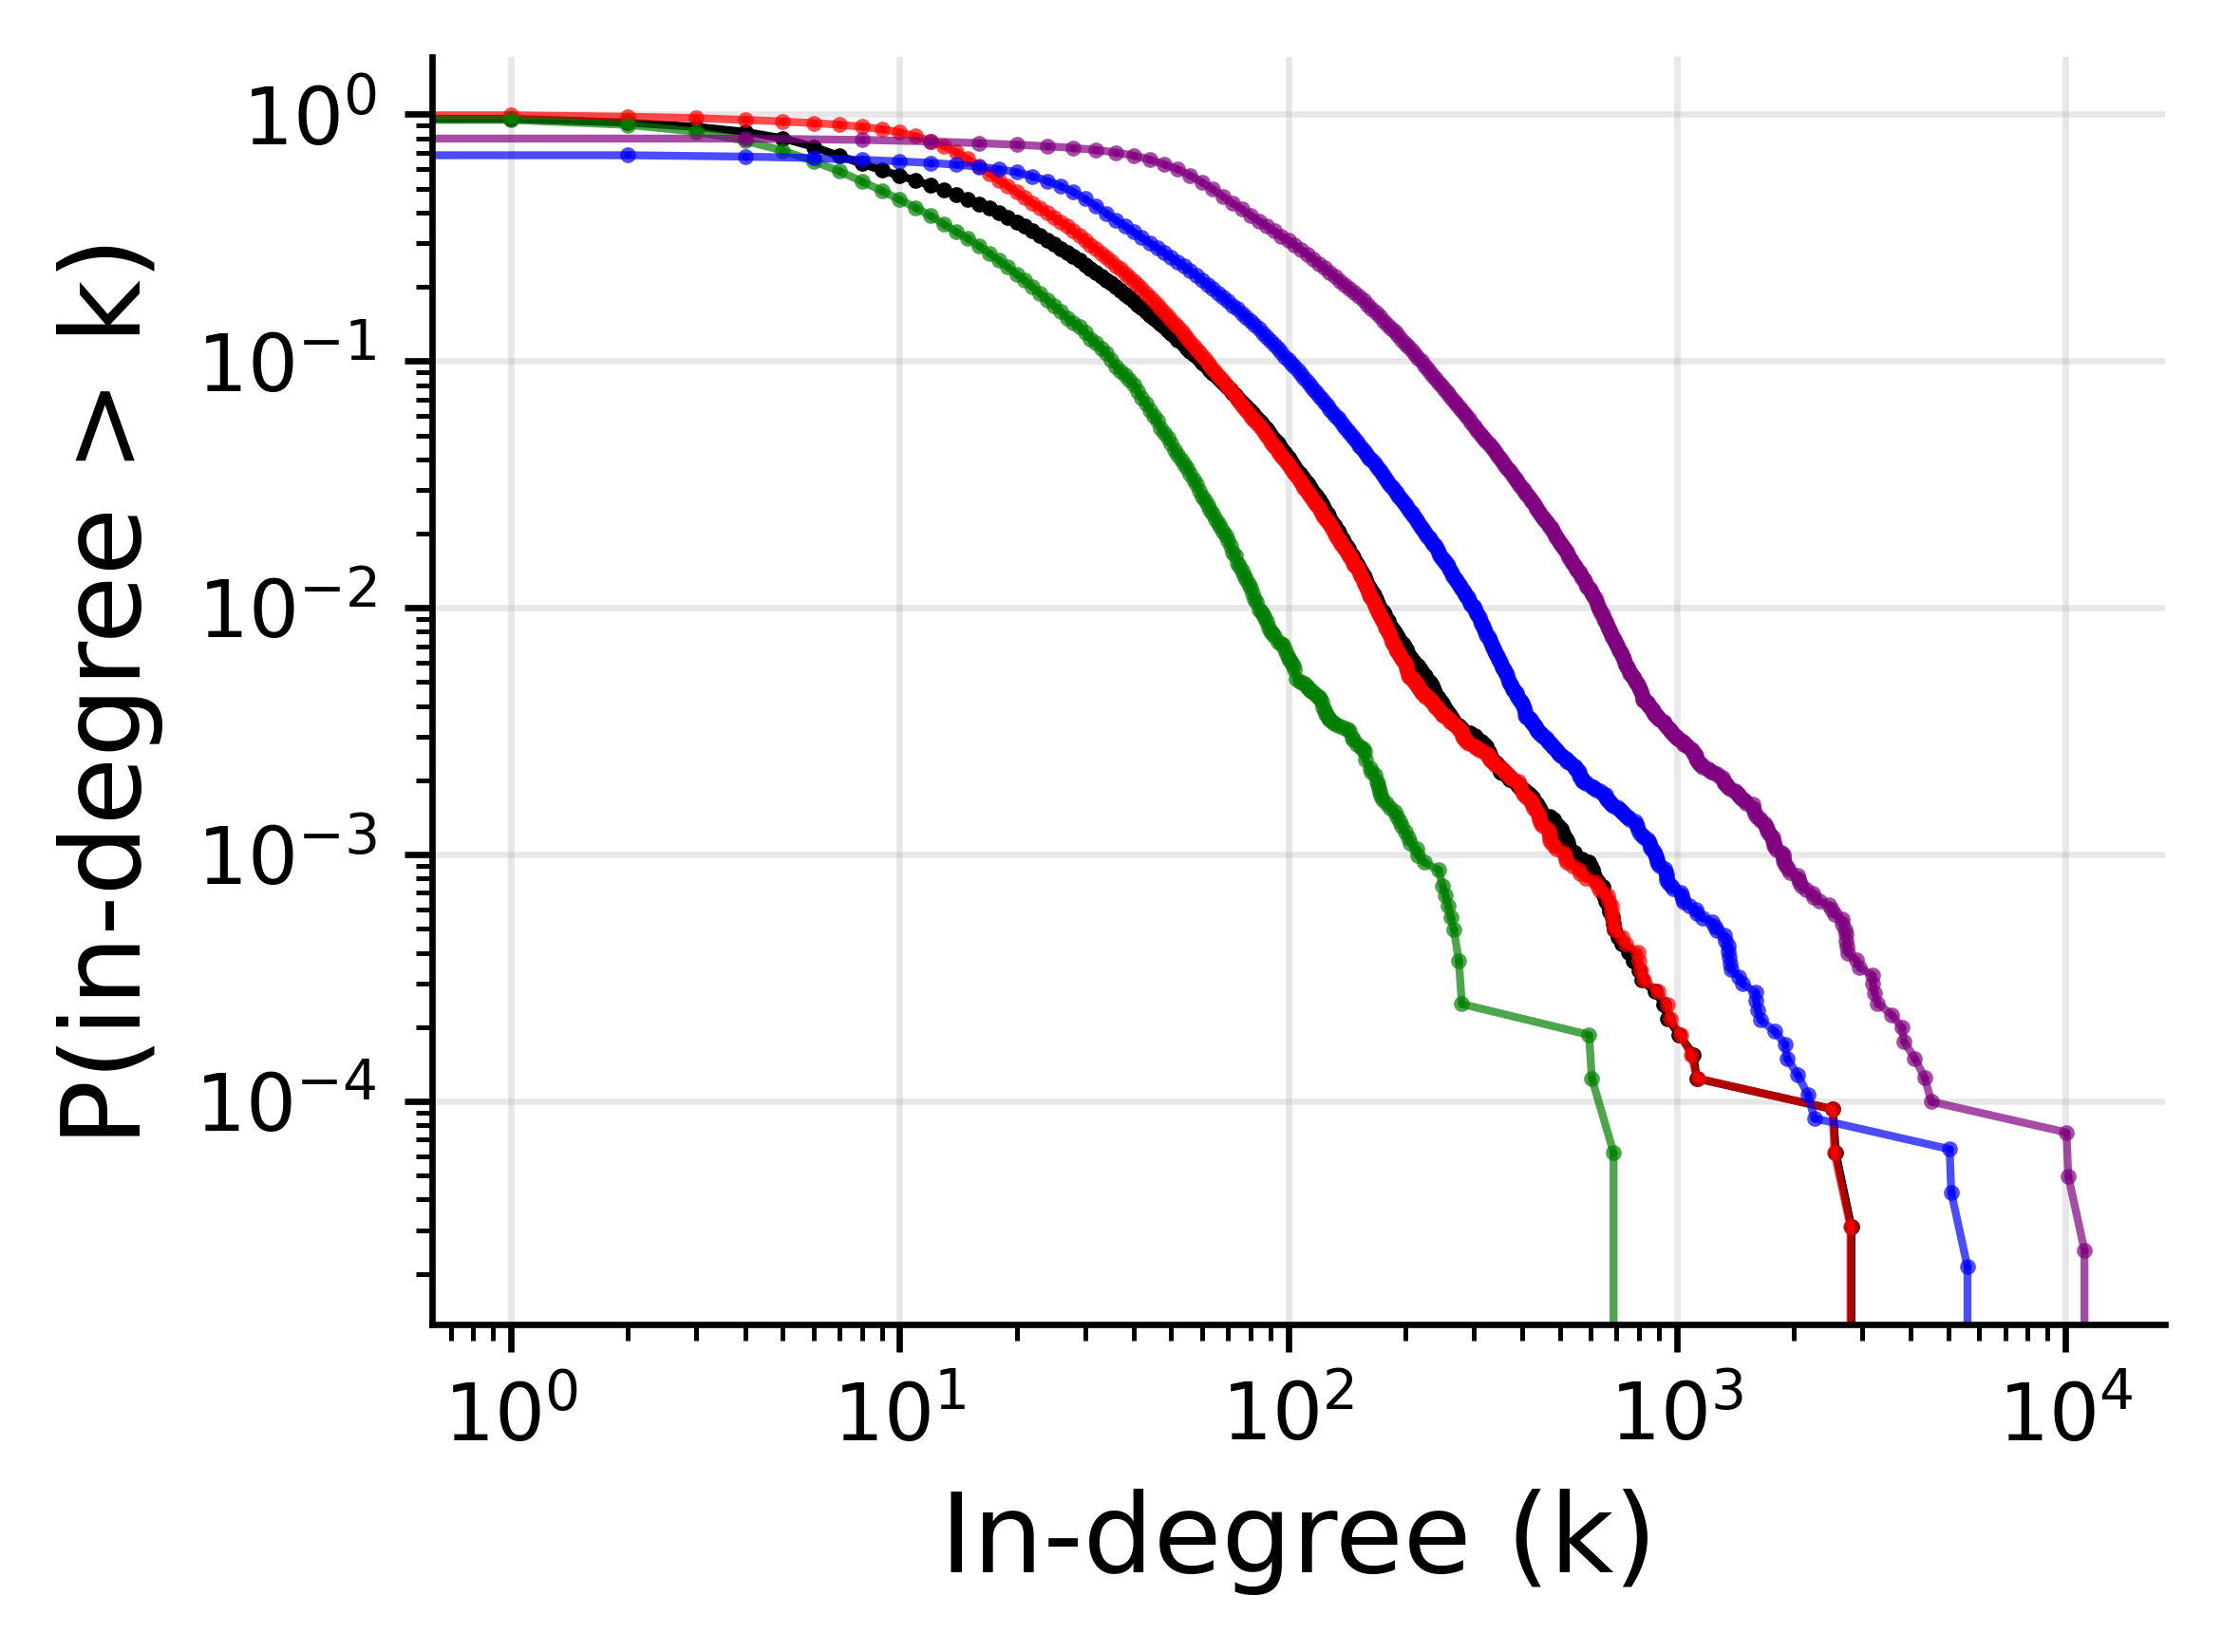

In [5]:
# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    alp = 1 if label == "Original Network" else 0.7
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=1,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
# plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
# plt.legend(fontsize=7)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_cumulative_in_degree.pdf', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

# # Plot cumulative out-degree distributions
# print("Plotting cumulative out-degree distributions...")
# plt.figure(figsize=(12, 8))

# for i, (G, label) in enumerate(zip(graphs, labels)):
#     out_degrees = [d for n, d in G.out_degree()]
#     out_degree_counts = Counter(out_degrees)
#     sorted_degrees = sorted(out_degree_counts.items())
    
#     x_vals = [k for k, _ in sorted_degrees]
#     y_vals = []
#     count_so_far = 0
#     total_nodes = G.number_of_nodes()
    
#     for _, count in sorted_degrees:
#         count_so_far += count
#         y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
#     plt.loglog(
#         x_vals,
#         y_vals,
#         marker='o',
#         markersize=4,
#         linewidth=1,
#         color=colors[i],
#         label=f"{label} Network"
#     )

# plt.grid(True, alpha=0.3)
# plt.xlabel('Out-degree (k)', fontsize=14)
# plt.ylabel('P(out-degree > k)', fontsize=14)
# plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
# print("Saved cumulative out-degree distribution comparison plot")

Plotting cumulative in-degree distributions...
Saved cumulative in-degree distribution comparison plot


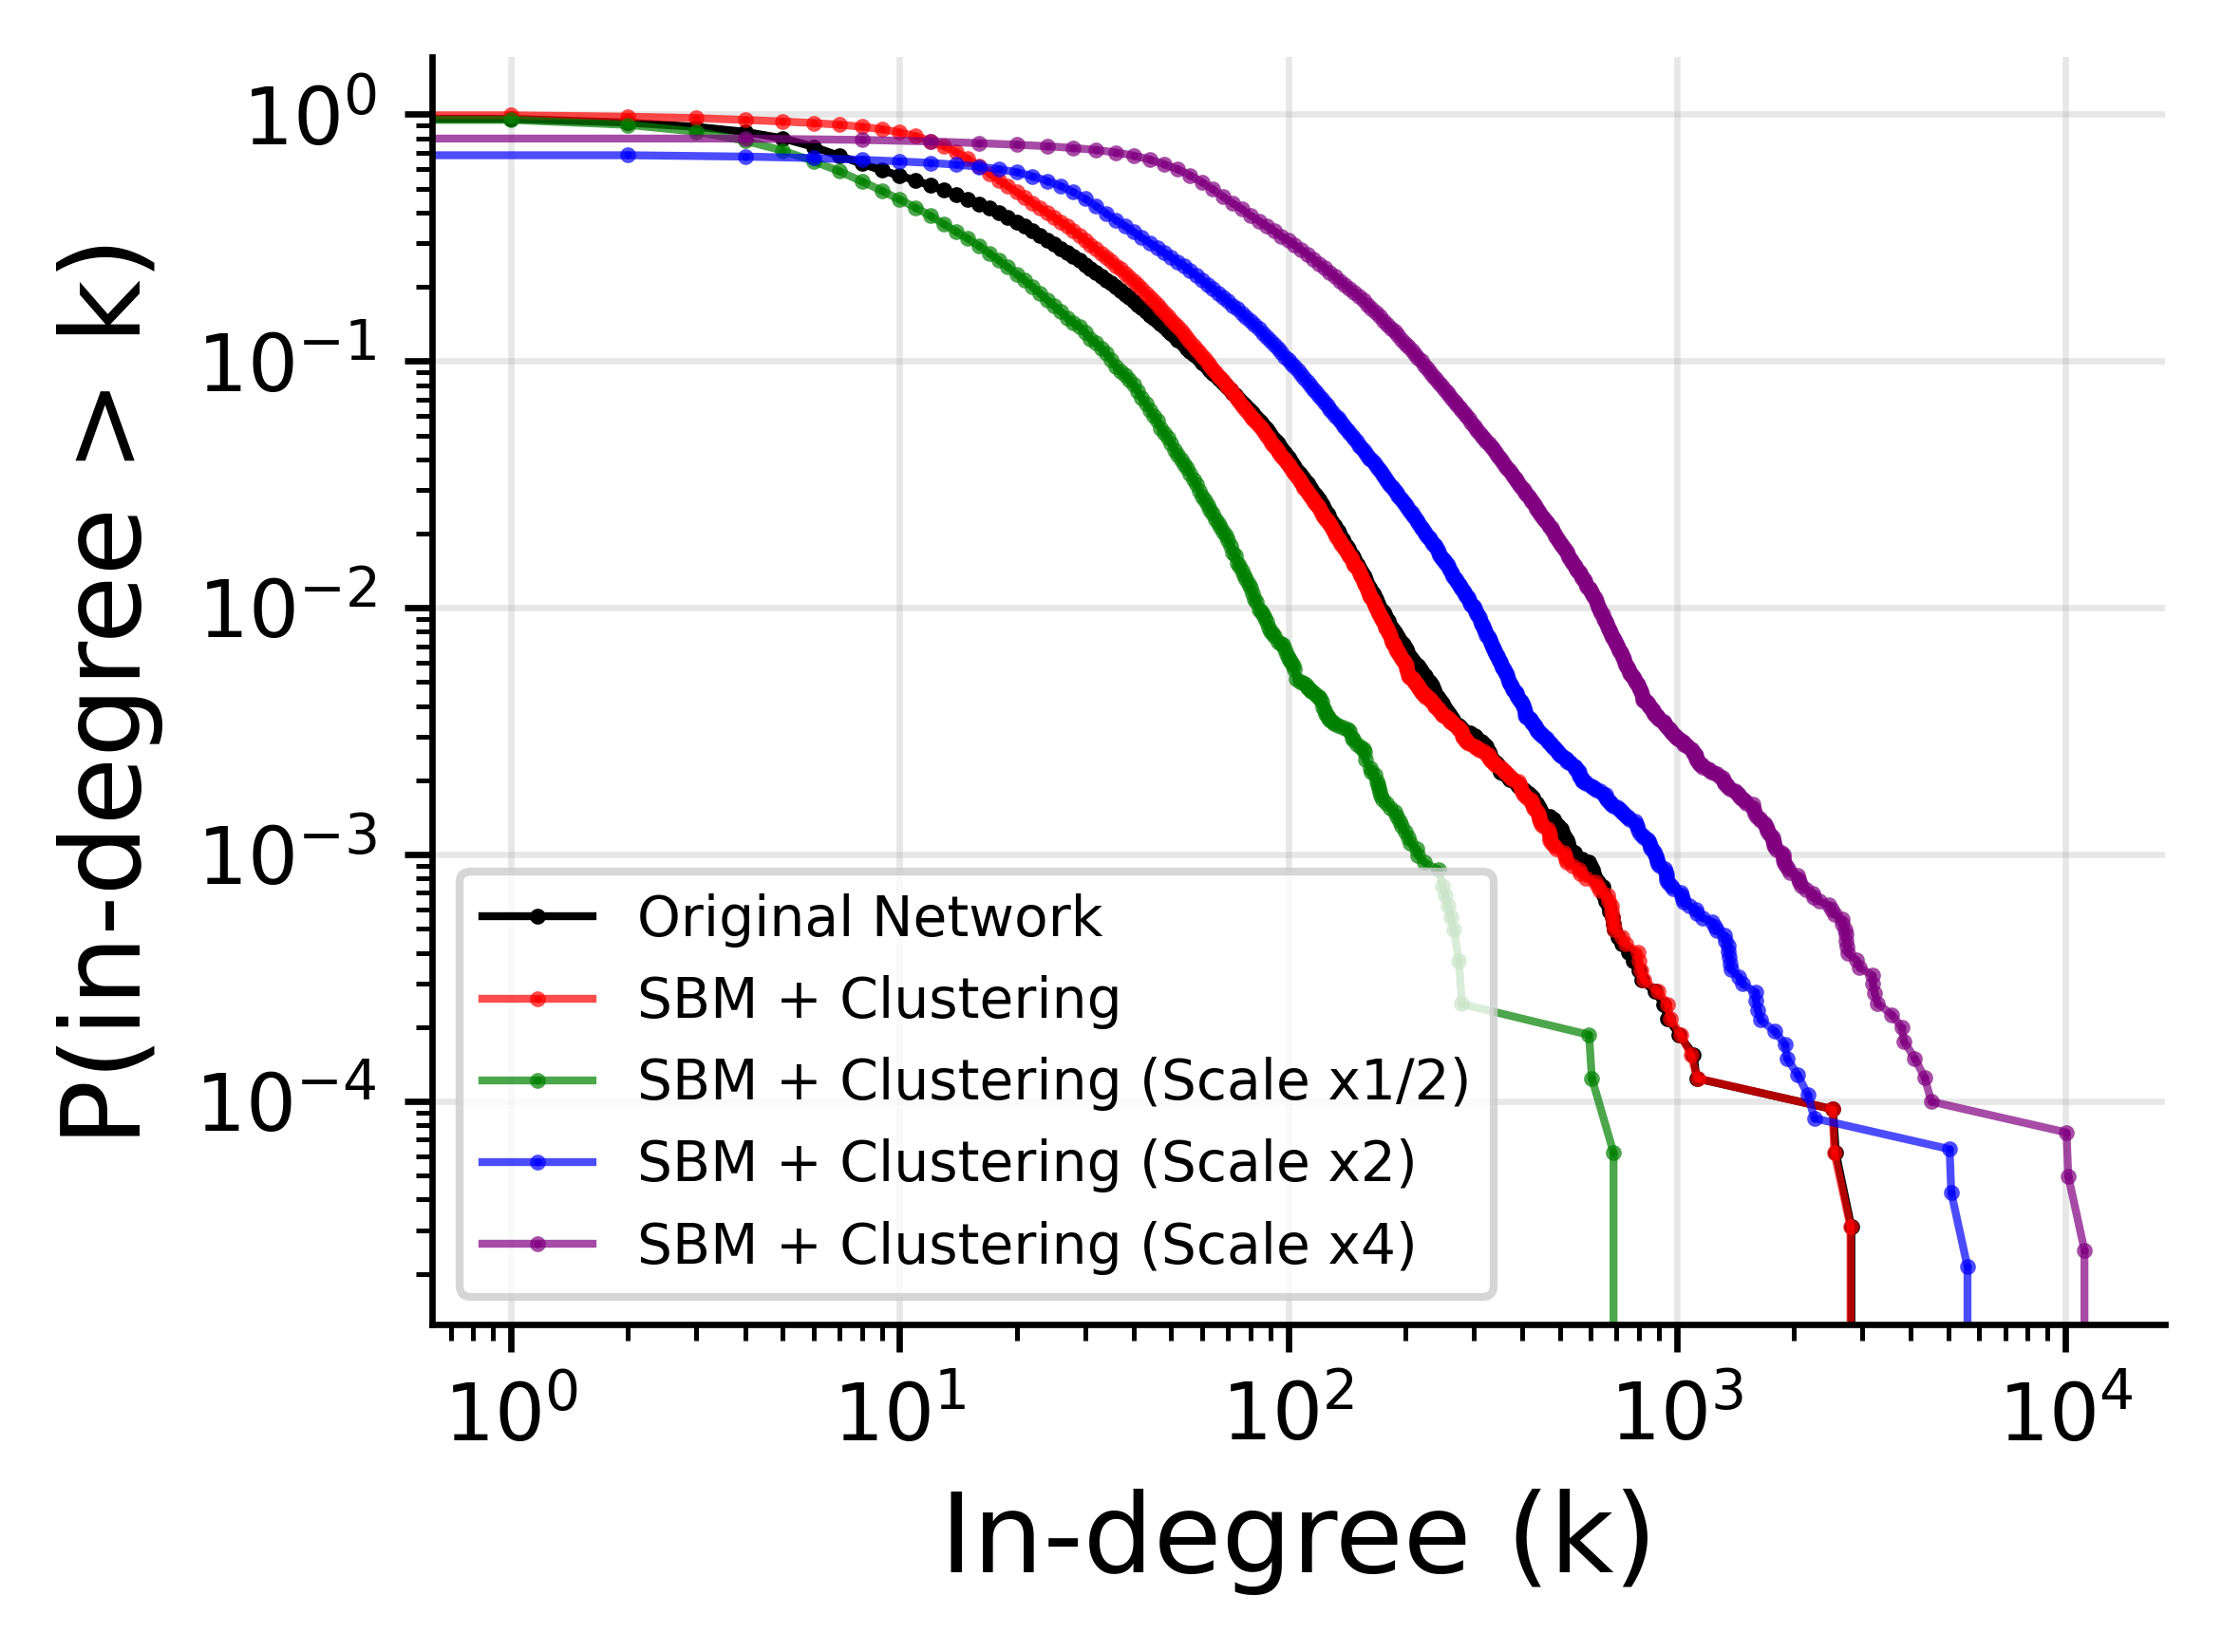

In [6]:
# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    alp = 1 if label == "Original Network" else 0.7
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=1,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
# plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=7)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_cumulative_in_degree.pdf', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

# # Plot cumulative out-degree distributions
# print("Plotting cumulative out-degree distributions...")
# plt.figure(figsize=(12, 8))

# for i, (G, label) in enumerate(zip(graphs, labels)):
#     out_degrees = [d for n, d in G.out_degree()]
#     out_degree_counts = Counter(out_degrees)
#     sorted_degrees = sorted(out_degree_counts.items())
    
#     x_vals = [k for k, _ in sorted_degrees]
#     y_vals = []
#     count_so_far = 0
#     total_nodes = G.number_of_nodes()
    
#     for _, count in sorted_degrees:
#         count_so_far += count
#         y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
#     plt.loglog(
#         x_vals,
#         y_vals,
#         marker='o',
#         markersize=4,
#         linewidth=1,
#         color=colors[i],
#         label=f"{label} Network"
#     )

# plt.grid(True, alpha=0.3)
# plt.xlabel('Out-degree (k)', fontsize=14)
# plt.ylabel('P(out-degree > k)', fontsize=14)
# plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
# print("Saved cumulative out-degree distribution comparison plot")

Plotting cumulative in-degree distributions, zoomed in on head...
Saved cumulative in-degree distribution comparison plot


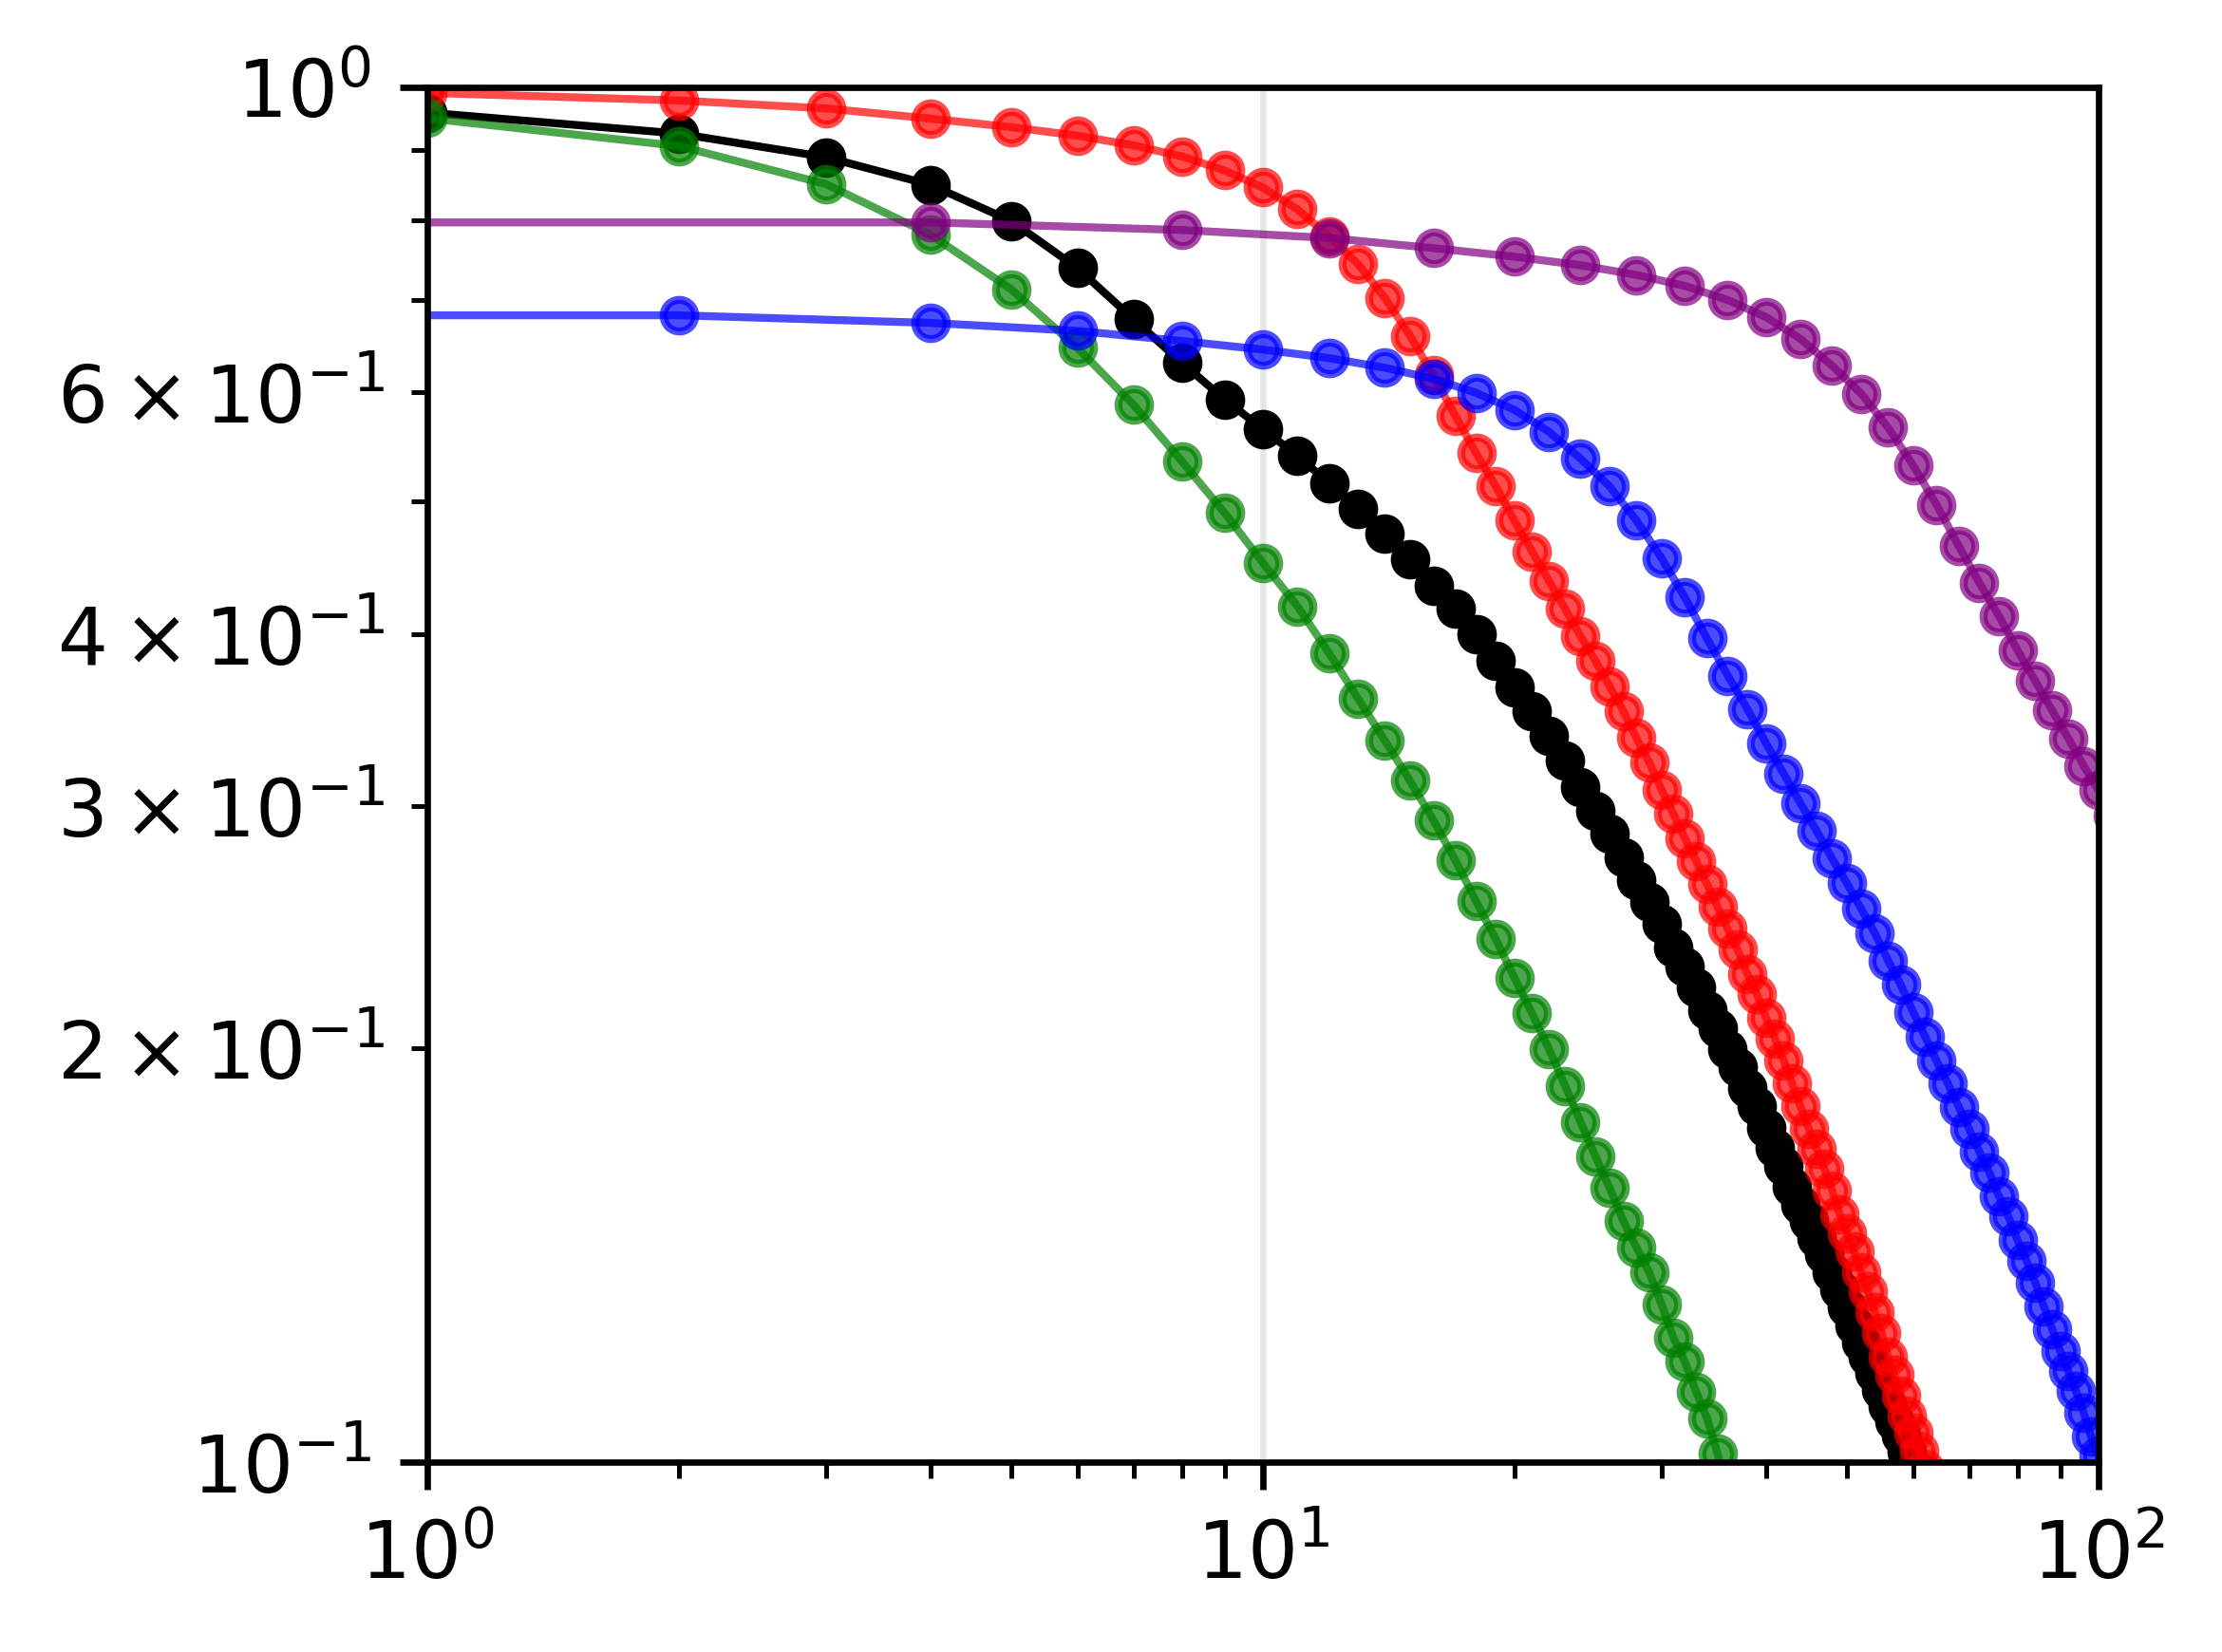

In [7]:
# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions, zoomed in on head...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    alp = 1 if label == "Original Network" else 0.7
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
# plt.xlabel('In-degree (k)', fontsize=14)
# plt.ylabel('P(in-degree > k)', fontsize=14)

plt.xlim(1e0, 1e2)   # Focus on high in-degrees
plt.ylim(1e-1,1e-0) # Focus on the tail probabilities

# plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
# plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_cumulative_in_degree_head.pdf', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

Plotting cumulative in-degree distributions, zoomed in on tail...
Saved cumulative in-degree distribution comparison plot


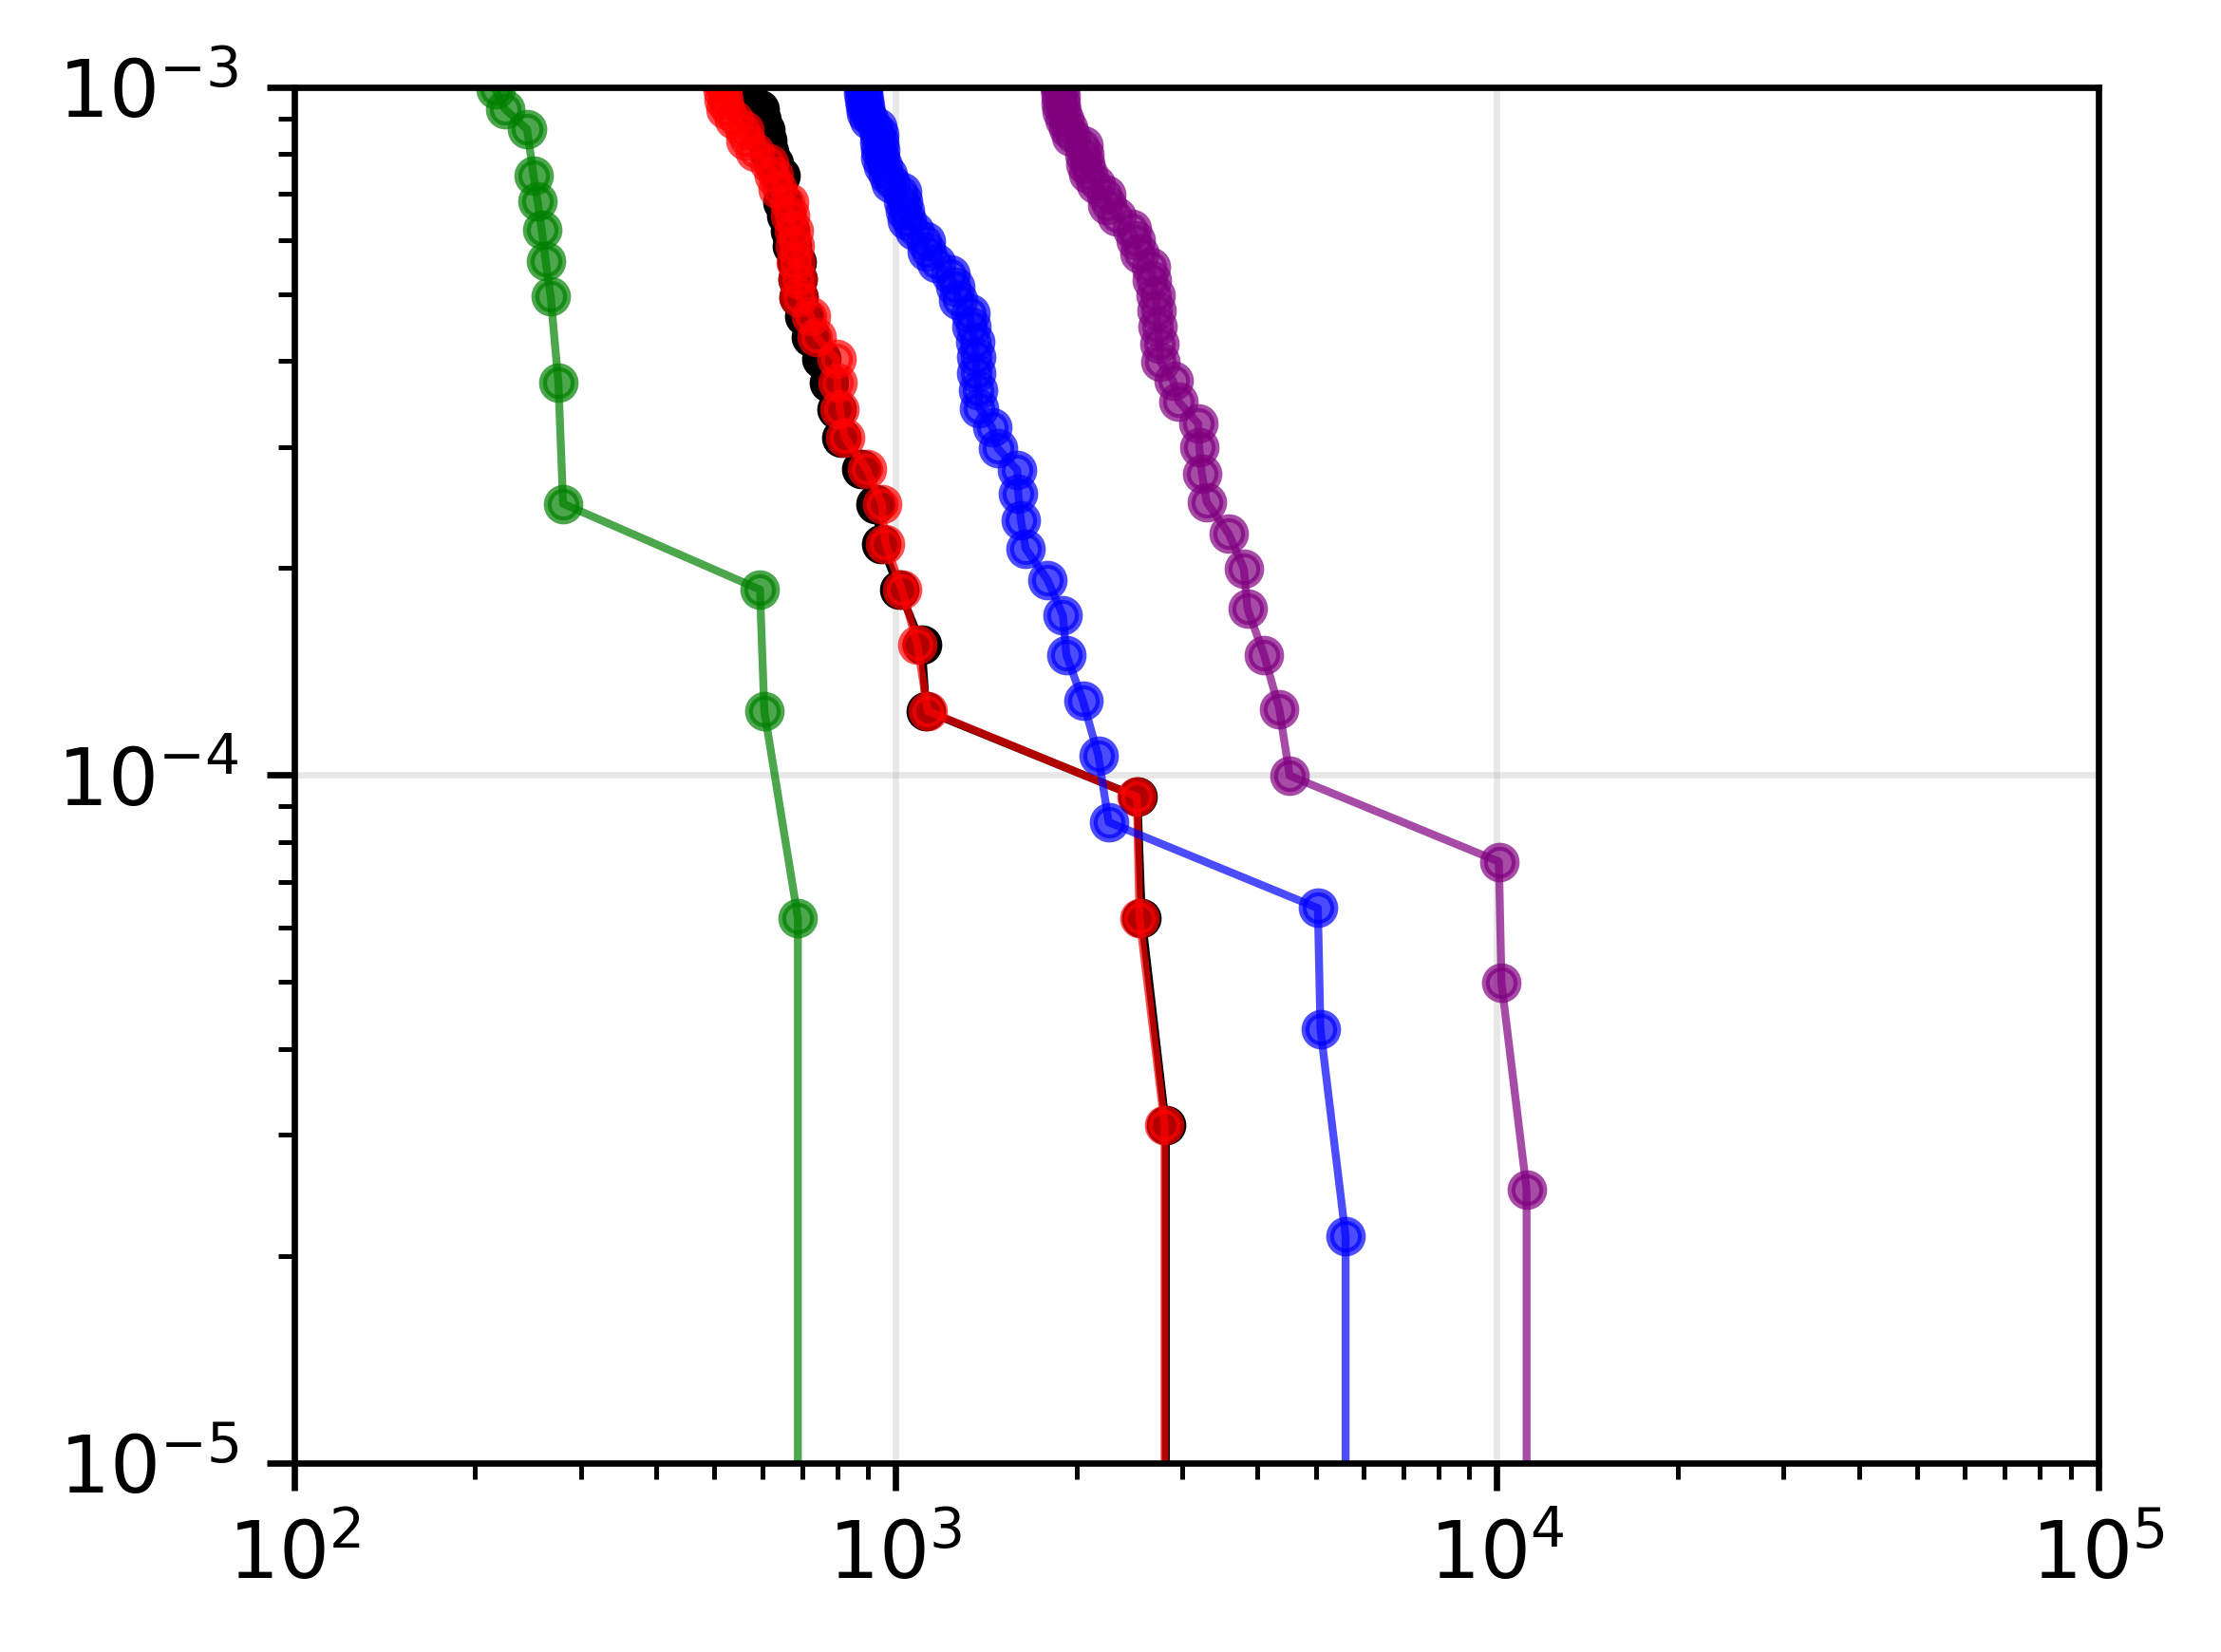

In [8]:
# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions, zoomed in on tail...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    alp = 1 if label == "Original Network" else 0.7
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
# plt.xlabel('In-degree (k)', fontsize=14)
# plt.ylabel('P(in-degree > k)', fontsize=14)

plt.xlim(1e2, 1e5)   # Focus on high in-degrees
plt.ylim(1e-5, 1e-3) # Focus on the tail probabilities

# plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
# plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_cumulative_in_degree_tail.pdf', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

Plotting cumulative out-degree distributions...
Saved cumulative in-degree distribution comparison plot


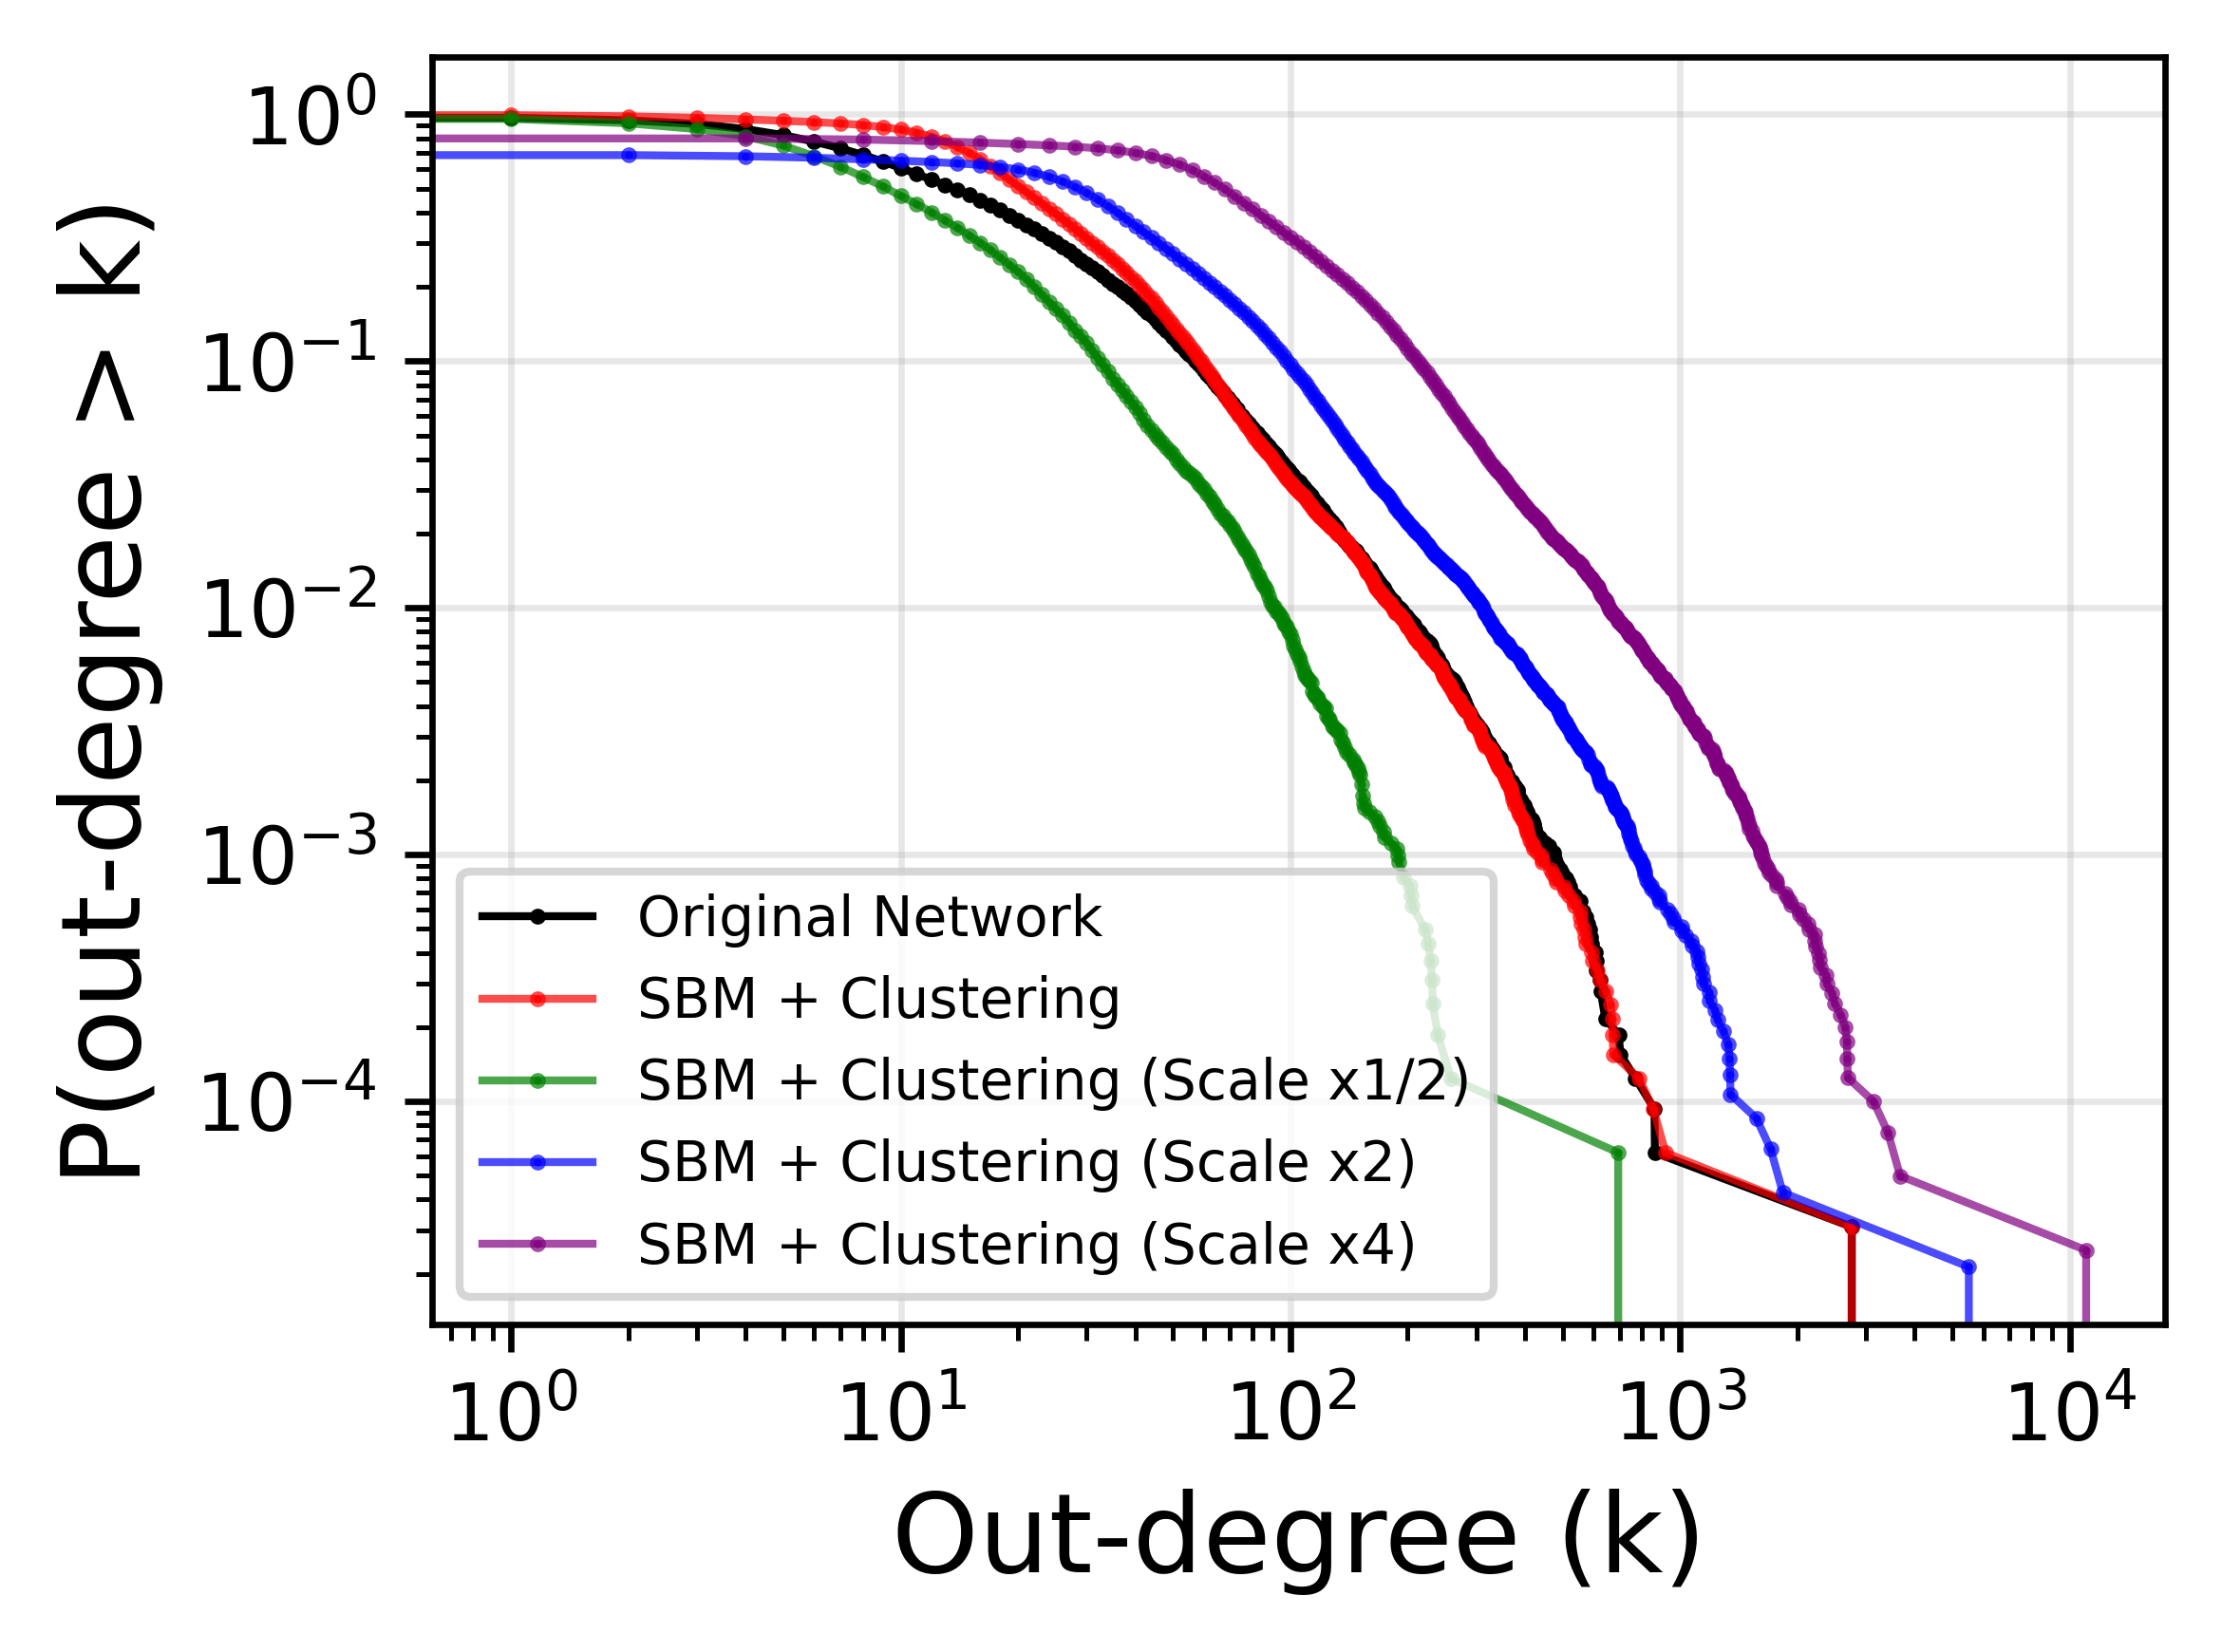

In [9]:
# Plot cumulative out-degree distributions
print("Plotting cumulative out-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    sorted_degrees = sorted(out_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    alp = 1 if label == "Original Network" else 0.7
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=1,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
# plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_cumulative_out_degree.pdf')
print("Saved cumulative in-degree distribution comparison plot")

Calculating directed clustering coefficients...
Calculating directed clustering for Original Network network...
Original Network network average directed clustering: 0.1583
Calculating directed clustering for SBM + Clustering network...
SBM + Clustering network average directed clustering: 0.1193
Calculating directed clustering for SBM + Clustering (Scale x1/2) network...
SBM + Clustering (Scale x1/2) network average directed clustering: 0.0708
Calculating directed clustering for SBM + Clustering (Scale x2) network...
SBM + Clustering (Scale x2) network average directed clustering: 0.0448
Calculating directed clustering for SBM + Clustering (Scale x4) network...
Sampled 100000 nodes for clustering calculation
SBM + Clustering (Scale x4) network average directed clustering: 0.0712
Plotting clustering coefficient distributions...
Saved directed clustering coefficient distribution comparison plot


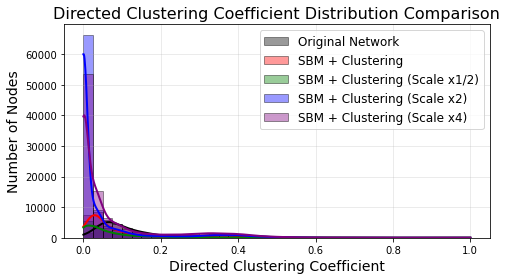

In [11]:
# Define directed clustering coefficient function
def directed_clustering_coefficient(G):
    """Calculate directed clustering coefficient for each node in the graph."""
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        preds = set(G.predecessors(node))
        succs = set(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0 or undefined (we'll use 0)
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in preds:
            for succ in succs:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Calculate and plot clustering coefficients
print("Calculating directed clustering coefficients...")
clustering_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating directed clustering for {label} network...")
    
    if label == "Original Network":
            clustering = nx.clustering(G_original)
    else:
        # Sample nodes for large networks to speed up calculation
        if G.number_of_nodes() > 100000:
            sample_nodes = random.sample(list(G.nodes()), 100000)
            subgraph = G.subgraph(sample_nodes)
            clustering = directed_clustering_coefficient(subgraph)
            print(f"Sampled {len(sample_nodes)} nodes for clustering calculation")
        else:
            clustering = directed_clustering_coefficient(G)
    
    clustering_data[label] = list(clustering.values())
    print(f"{label} network average directed clustering: {np.mean(list(clustering.values())):.4f}")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(7, 4))
bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

for i, label in enumerate(labels):
    values = clustering_data[label]
    plt.hist(
        values,
        bins=bins,
        alpha=0.4,
        color=colors[i],
        edgecolor='black',
        label=f"{label}"
    )
    
    # Add kernel density estimation if there are enough values
    if len(values) > 10:
        kde = gaussian_kde(values)
        x_vals = np.linspace(0, 1, 1000)
        plt.plot(
            x_vals,
            kde(x_vals) * len(values) * (bins[1] - bins[0]),
            linewidth=2,
            color=colors[i]
        )

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_directed_clustering_coefficient.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot")

Plotting clustering coefficient distributions...
Saved directed clustering coefficient distribution comparison plot


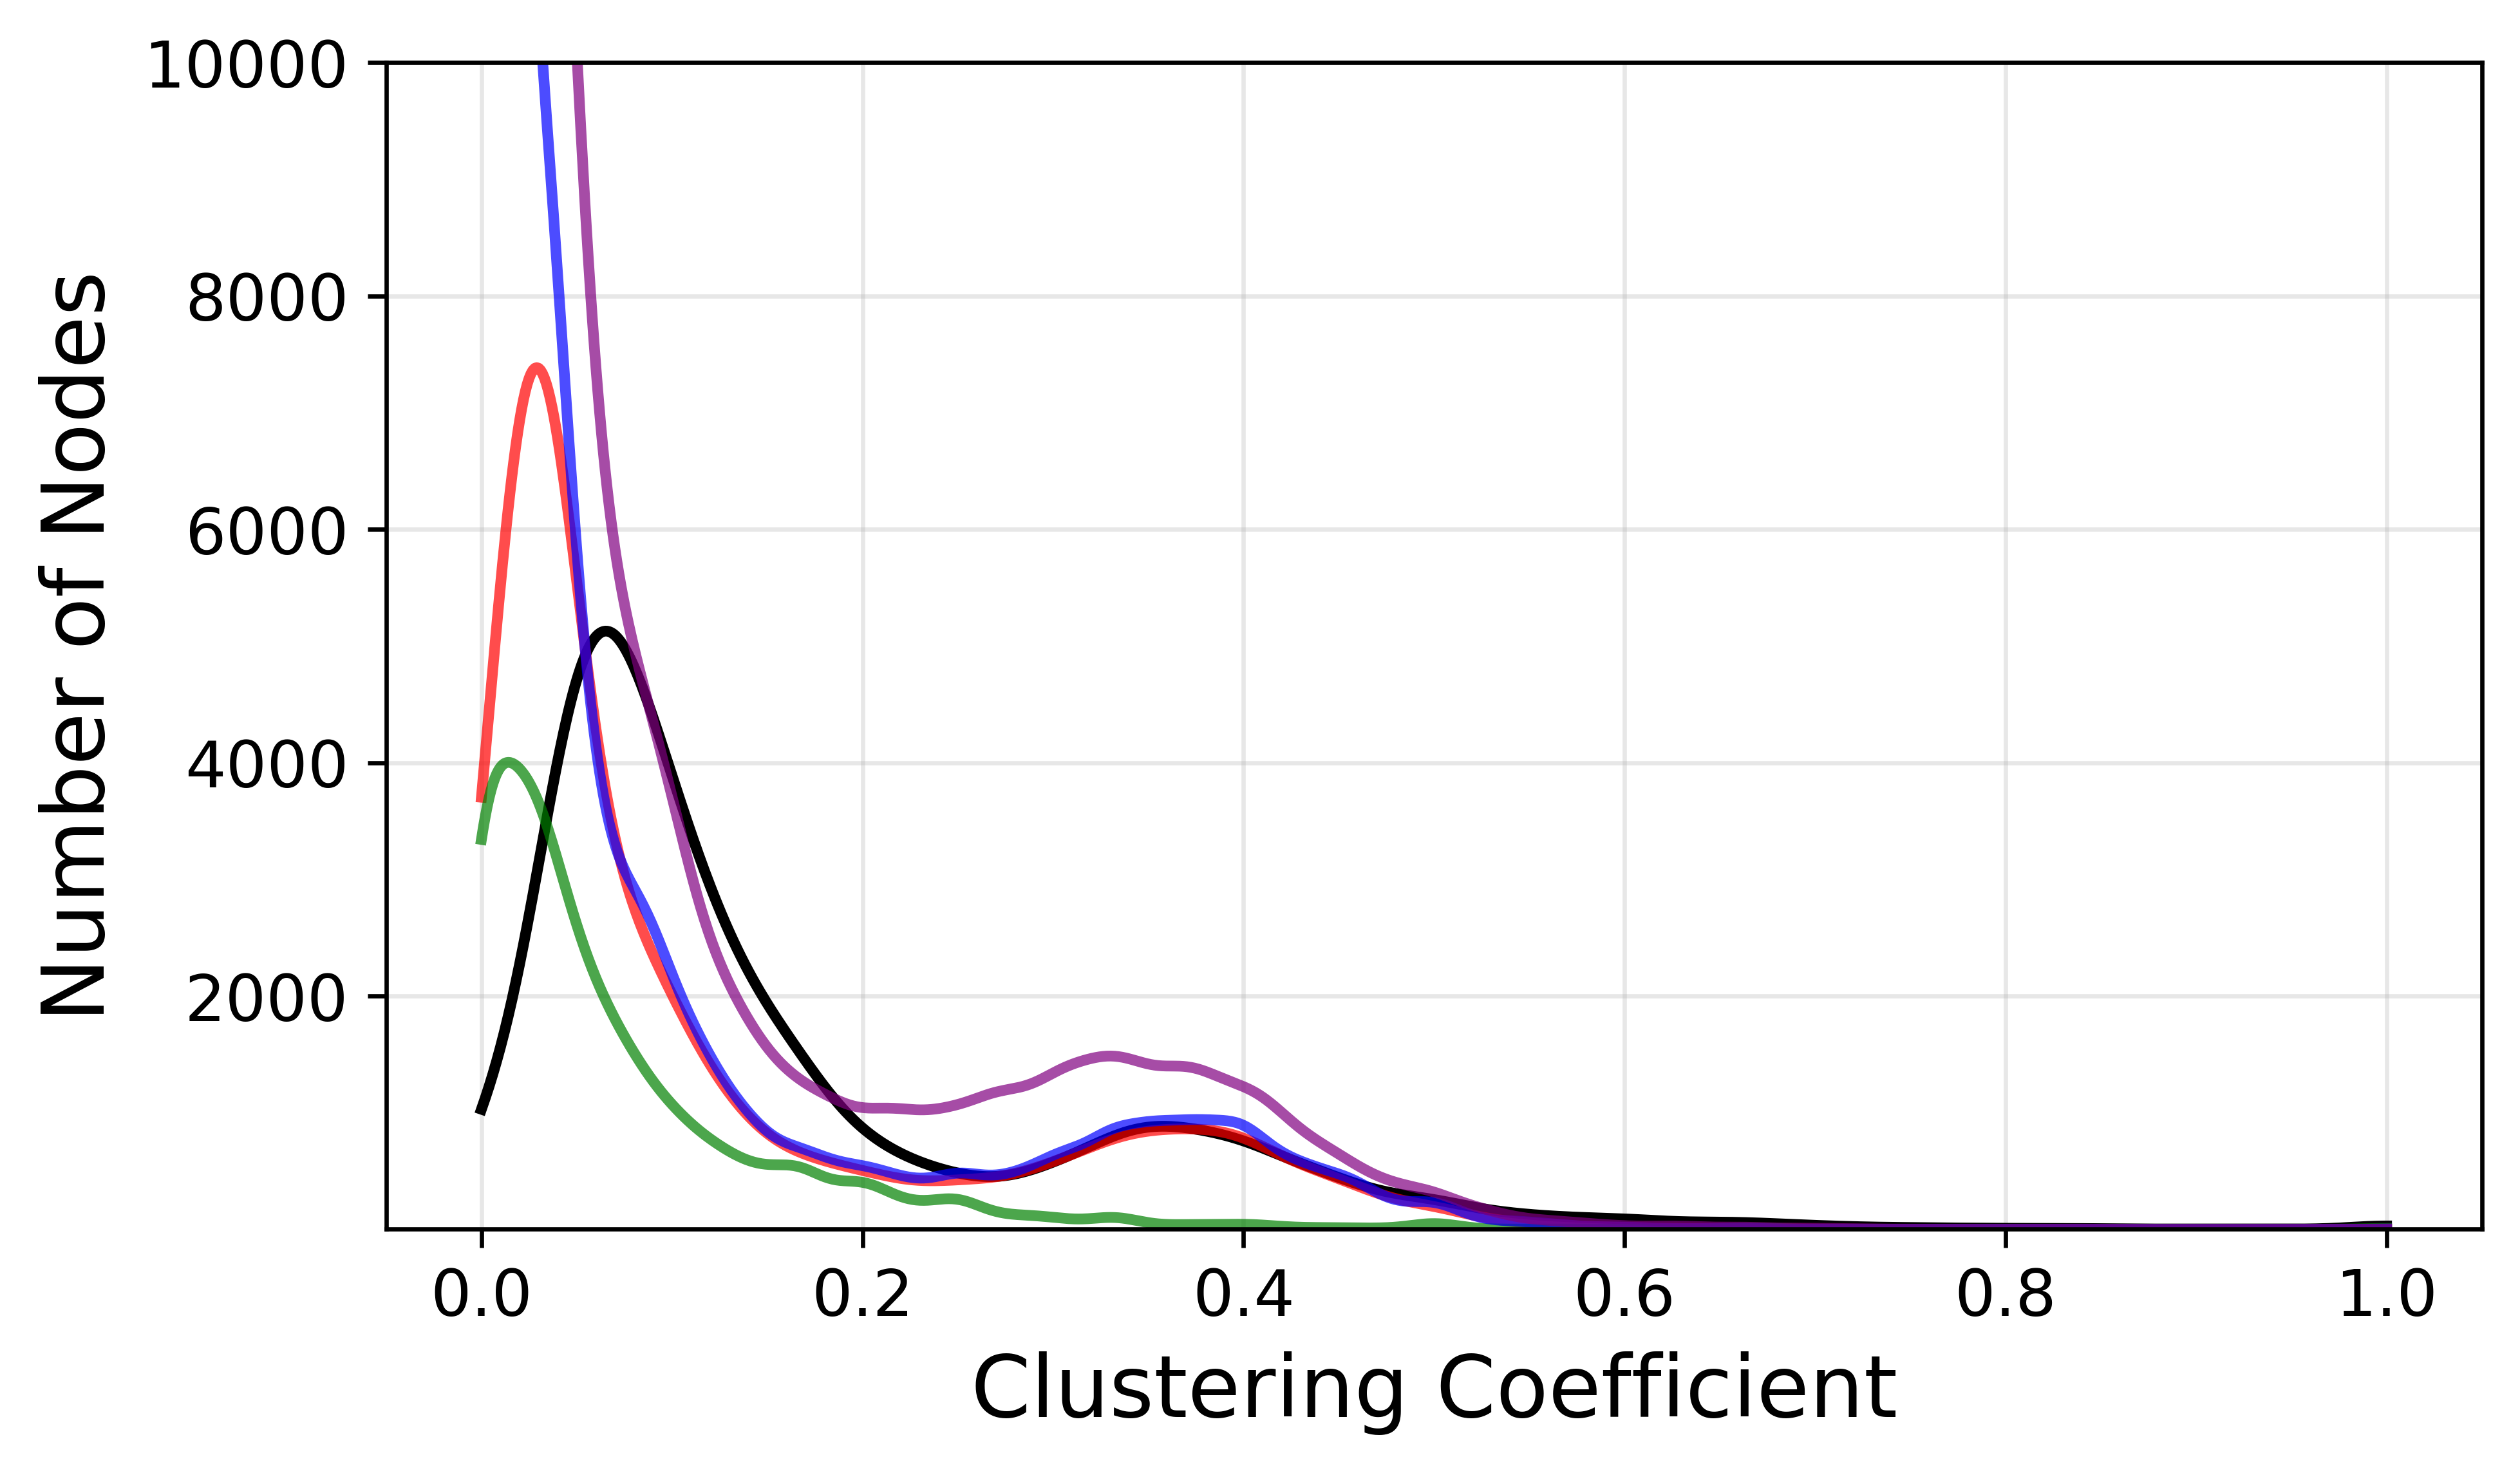

In [12]:
# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(7, 4),dpi=600)
bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

for i, label in enumerate(labels):
    values = clustering_data[label]
#     plt.hist(
#         values,
#         bins=bins,
#         color=colors[i],
#         edgecolor='black',
#         label=f"{label}",
#         alpha=1.0,
# #         histtype="step"
#     )

    alp = 1 if label == "Original Network" else 0.7
    
    # Add kernel density estimation if there are enough values
    if len(values) > 10:
        kde = gaussian_kde(values)
        x_vals = np.linspace(0, 1, 1000)
        plt.plot(
            x_vals,
            kde(x_vals) * len(values) * (bins[1] - bins[0]),
            linewidth=2,
            color=colors[i],
            alpha=alp
        )

plt.xlabel('Clustering Coefficient', fontsize=16)
plt.ylabel('Number of Nodes', fontsize=16)

# plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
# plt.legend(fontsize=12)
plt.ylim(1,10000)
plt.tick_params(axis='both', which='major', labelsize=12)  # Change tick label font size

plt.savefig('plots/bcnm__comparison_directed_clustering_coefficient.pdf', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot")

Plotting clustering coefficient distributions...
Saved directed clustering coefficient distribution comparison plot


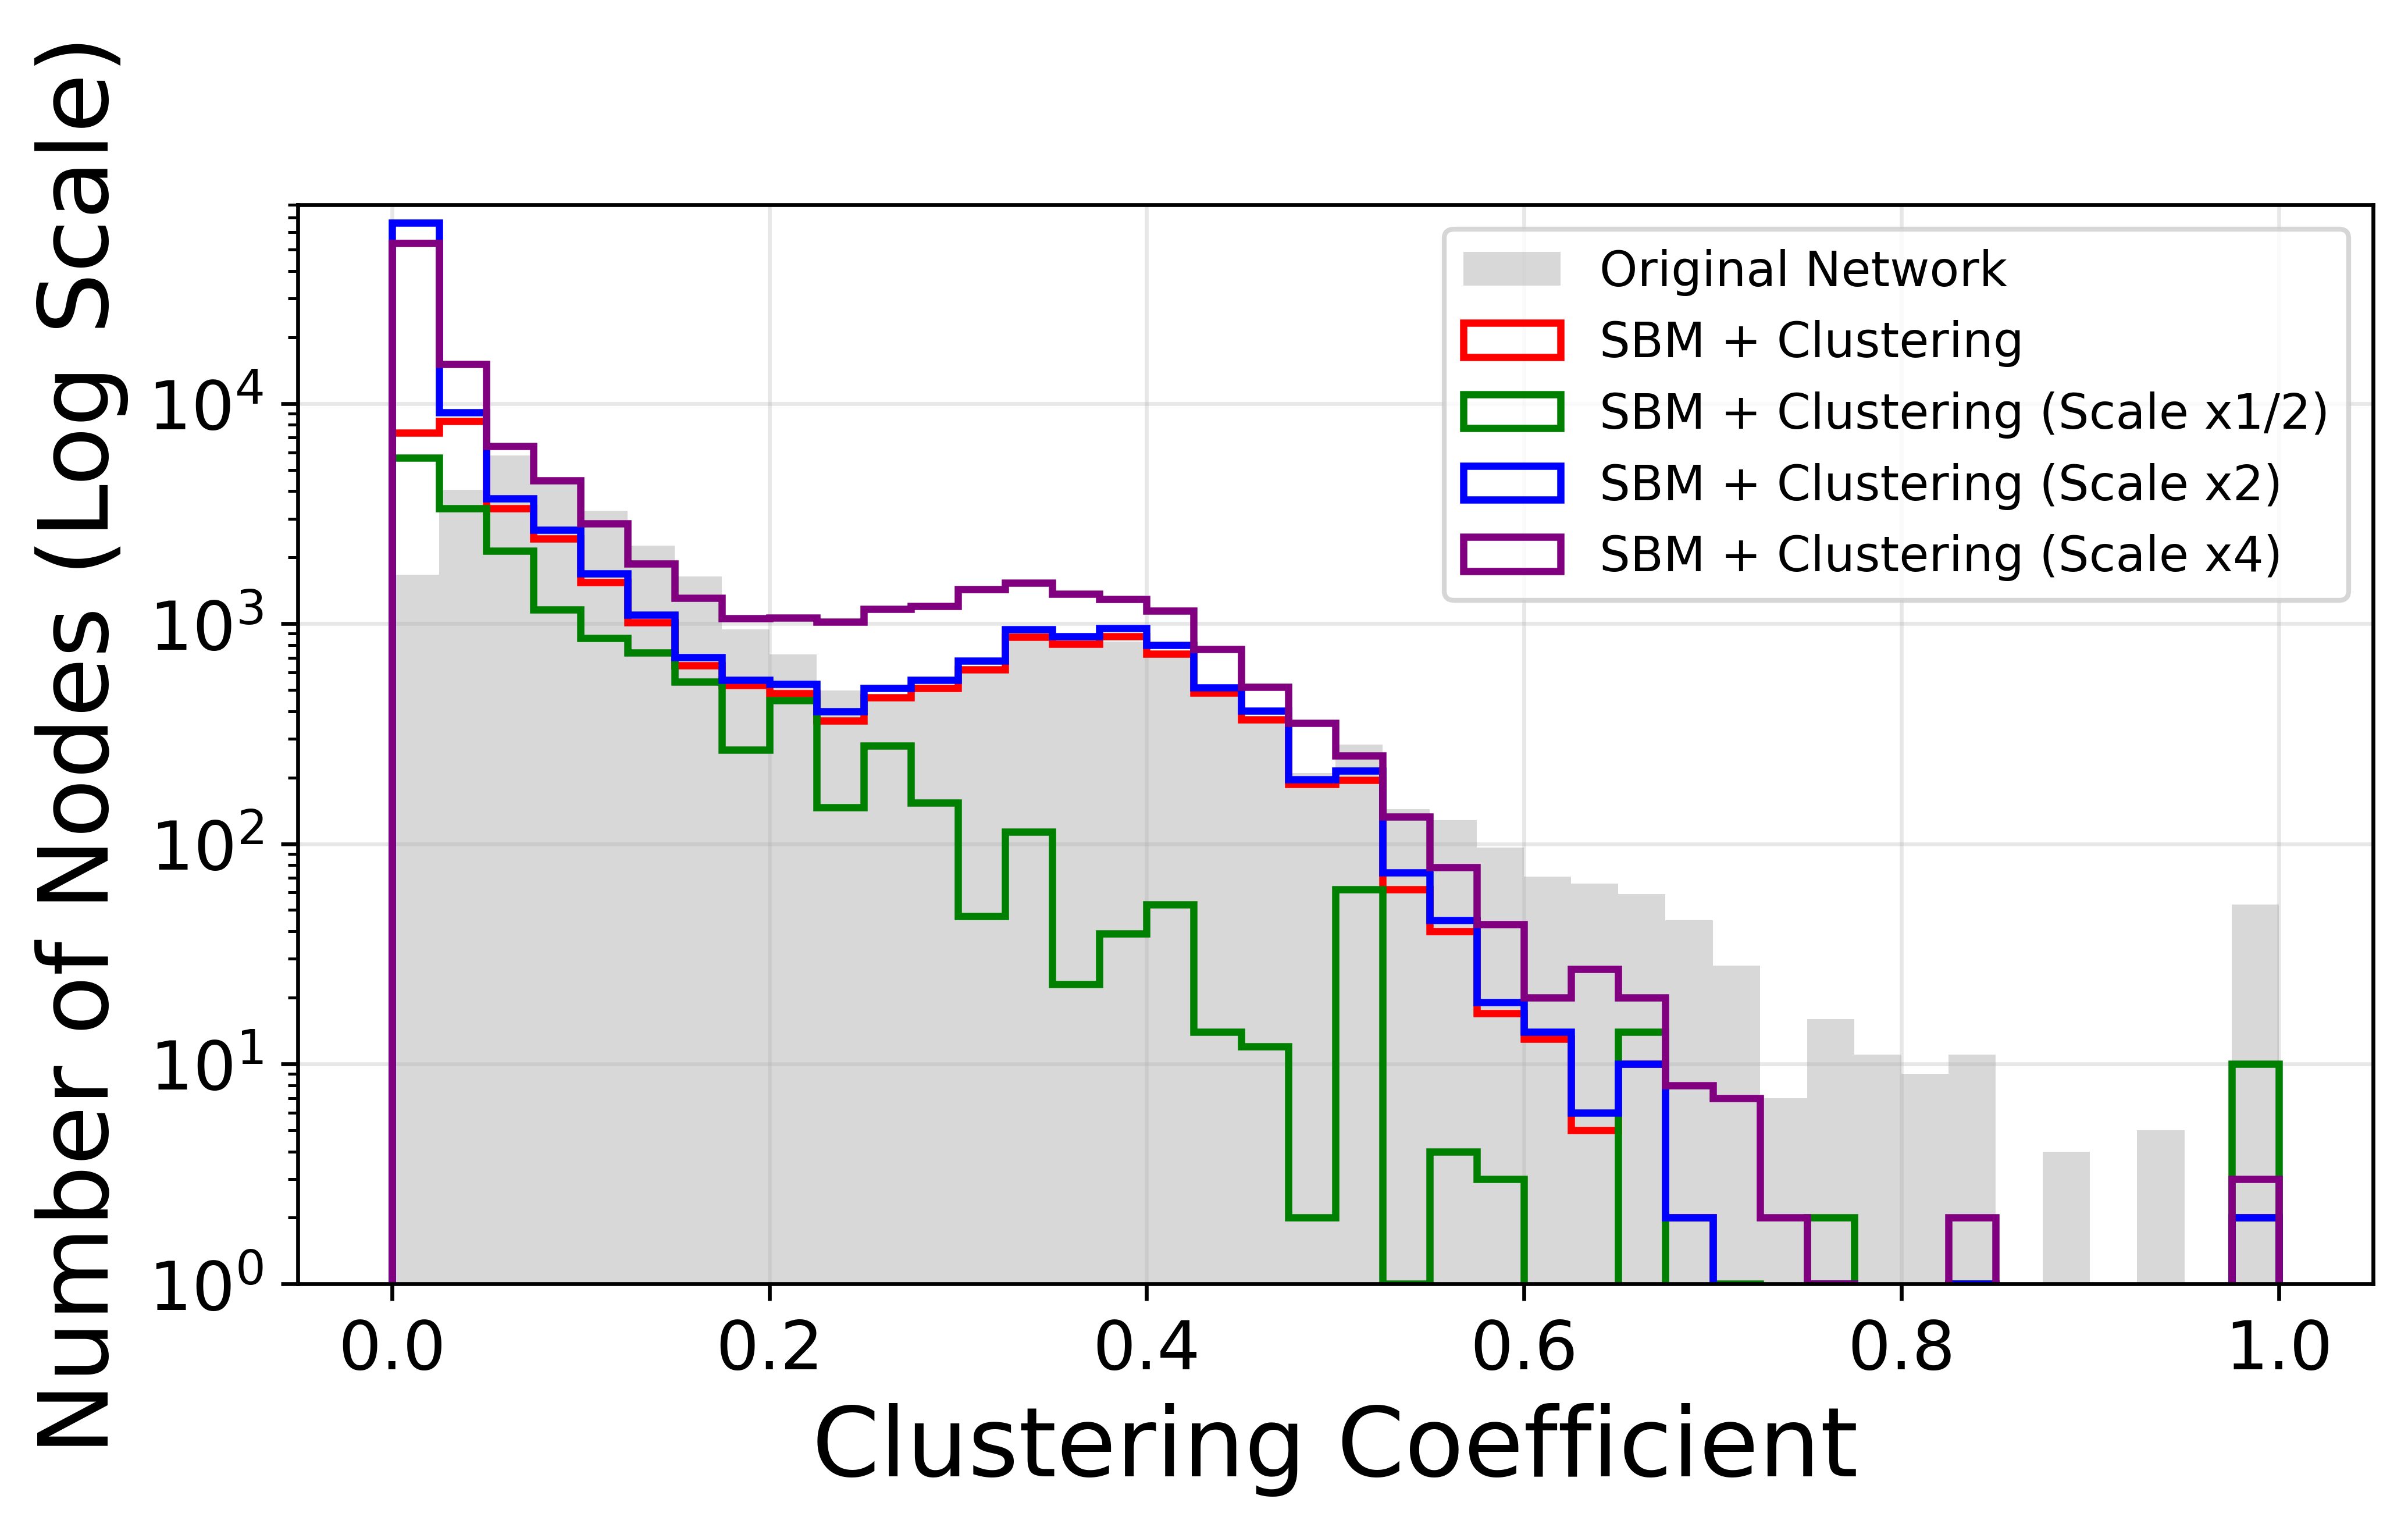

In [13]:
# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(7, 4), dpi=600)
bins = np.linspace(0, 1, 41)  # 40 bins from 0 to 1

# First plot Original Network as filled histogram with grey color and opacity 0.3
original_index = labels.index("Original Network")
original_values = clustering_data["Original Network"]
plt.hist(
    original_values,
    bins=bins,
    alpha=0.3,
    color='grey',
    label=f"{labels[original_index]}",
    histtype="bar",
    linewidth=1.5
)

# Then plot the rest as step histograms
for i, label in enumerate(labels):
    if label != "Original Network":  # Skip the Original Network since we already plotted it
        values = clustering_data[label]
        plt.hist(
            values,
            bins=bins,
            alpha=1,
            color=colors[i],
            label=f"{label}",
            histtype="step",
            linewidth=1.5
        )

plt.xlabel('Clustering Coefficient', fontsize=20)
plt.ylabel('Number of Nodes (Log Scale)', fontsize=20)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.ylim(1, 80000)
plt.legend()
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bcnm_stephist_comparison_directed_clustering_coefficient.pdf')
print("Saved directed clustering coefficient distribution comparison plot")

Calculating connection distances...
Calculating distances for Original Network network...
Processing all 849981 edges for distance calculation
Original Network network: 849981 distances calculated, avg = 118124.9203
Calculating distances for SBM + Clustering network...
Processing all 1011690 edges for distance calculation
SBM + Clustering network: 1011690 distances calculated, avg = 129603.4954
Calculating distances for SBM + Clustering (Scale x1/2) network...
Processing all 251728 edges for distance calculation
SBM + Clustering (Scale x1/2) network: 251728 distances calculated, avg = 129351.6880
Calculating distances for SBM + Clustering (Scale x2) network...
Processing all 4046760 edges for distance calculation
SBM + Clustering (Scale x2) network: 2211752 distances calculated, avg = 129661.1334
Calculating distances for SBM + Clustering (Scale x4) network...
Processing all 16187040 edges for distance calculation
SBM + Clustering (Scale x4) network: 12254880 distances calculated, avg 

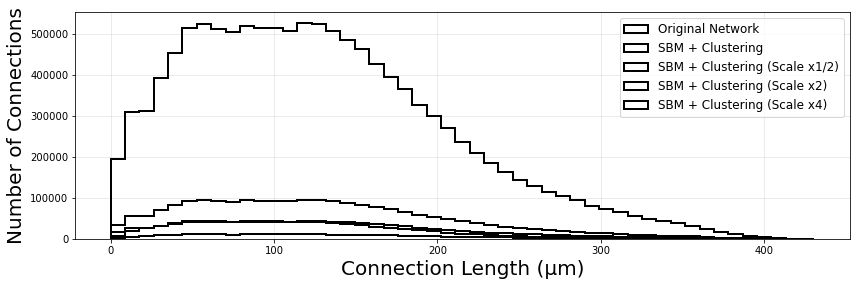

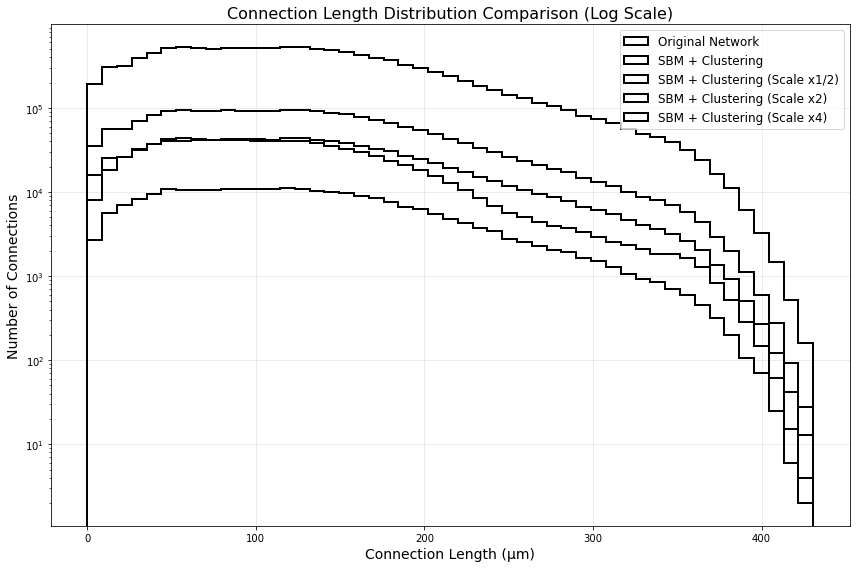

In [14]:
# Calculate and plot connection distances
print("Calculating connection distances...")
distance_data = {}
for G, label in zip(graphs, labels):
    print(f"Calculating distances for {label} network...")
    # Use all edges for the distance calculation as requested
    print(f"Processing all {G.number_of_edges()} edges for distance calculation")
    
    distances = []
    for edge in G.edges():
        distance = calculate_euclidean_distance(G, edge)
        if distance is not None:
            distances.append(distance)
    
    distance_data[label] = distances
    print(f"{label} network: {len(distances)} distances calculated, avg = {np.mean(distances):.4f}")

# Plot connection distance distributions
print("Plotting connection distance distributions...")
plt.figure(figsize=(12, 4))

# Convert nm to μm for all distances
distance_data_um = {}
for label, distances in distance_data.items():
    distance_data_um[label] = [d / 1000.0 for d in distances]

# Calculate max distance in μm for binning
max_distance_um = max([max(distances) for distances in distance_data_um.values() if distances])
bins = np.linspace(0, max_distance_um, 50)

for i, label in enumerate(labels):
    distances_um = distance_data_um[label]
    if distances_um:
        plt.hist(
            distances_um,
            bins=bins,
            alpha=1,
            color=colors[i],
            edgecolor='black',
            label=f"{label}",
            linewidth=2,
            histtype="step"
        )
plt.xlabel('Connection Length (µm)', fontsize=20)
plt.ylabel('Number of Connections', fontsize=20)
# plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot")

# Plot connection distance distributions with log scale
print("Plotting connection distance distributions with log scale...")
plt.figure(figsize=(12, 8))
for i, label in enumerate(labels):
    distances_um = distance_data_um[label]
    if distances_um:
        plt.hist(
            distances_um,
            bins=bins,
            alpha=1,
            color=colors[i],
            edgecolor='black',
            label=f"{label}",
            histtype="step",  # Fixed: Changed plottype to histtype
            linewidth=2
        )
plt.xlabel('Connection Length (µm)', fontsize=14)  # Updated to show μm instead of Euclidean
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot")

Plotting connection distance distributions with log scale...
Saved log-scale connection length distribution comparison plot


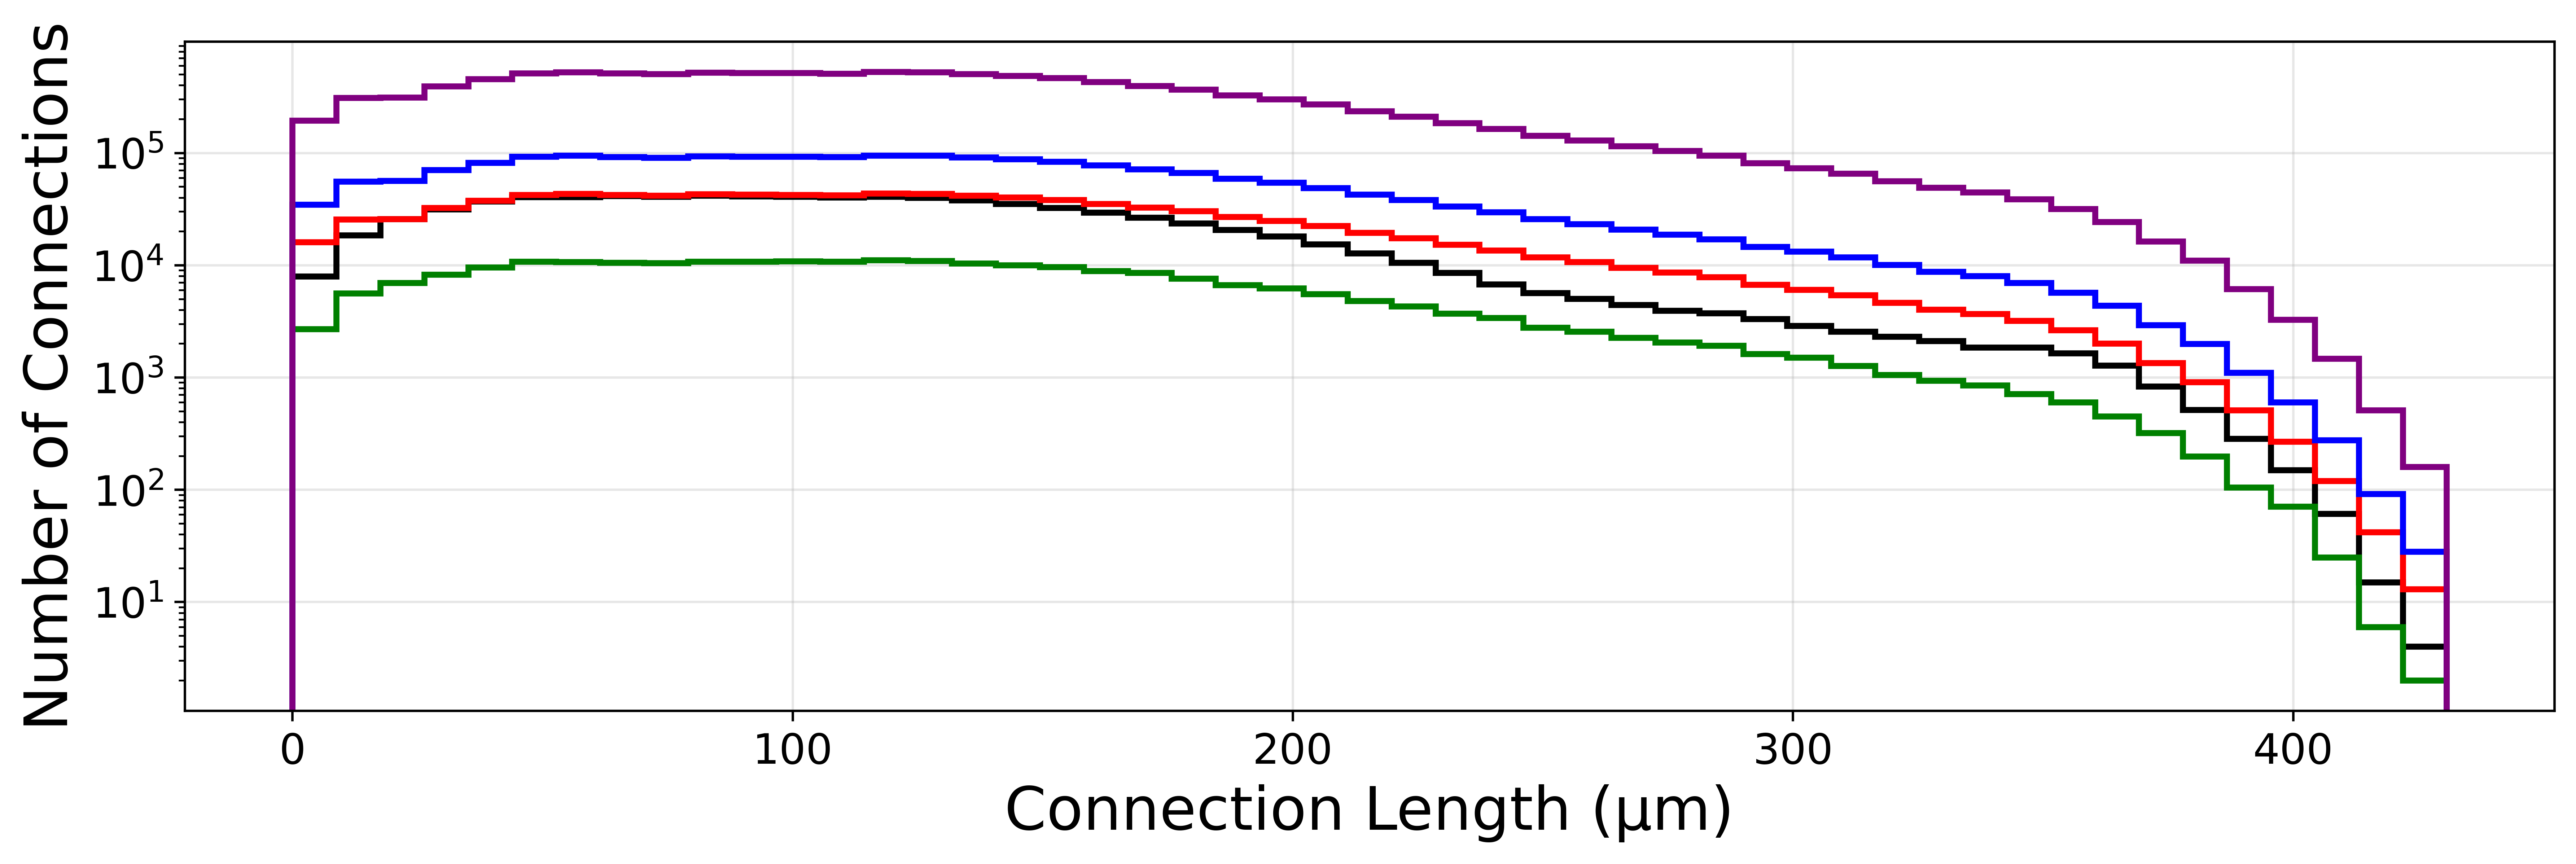

In [15]:
# Plot connection distance distributions with log scale
print("Plotting connection distance distributions with log scale...")
plt.figure(figsize=(12, 4), dpi=600)
for i, label in enumerate(labels):
    distances_um = distance_data_um[label]
    if distances_um:
        plt.hist(
            distances_um,
            bins=bins,
            alpha=1,
            color=colors[i],
            label=f"{label}",
            histtype="step",  # Fixed: Changed plottype to histtype
            linewidth=2
        )
plt.xlabel('Connection Length (µm)', fontsize=20)  # Updated to show μm instead of Euclidean
plt.ylabel('Number of Connections', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size
plt.yscale('log')
# plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=14)
plt.grid(True, alpha=0.3)
# plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_connection_length_log.pdf', dpi=600)
print("Saved log-scale connection length distribution comparison plot")

Plotting connection distance distributions with log scale...
Saved log-scale connection length distribution comparison plot


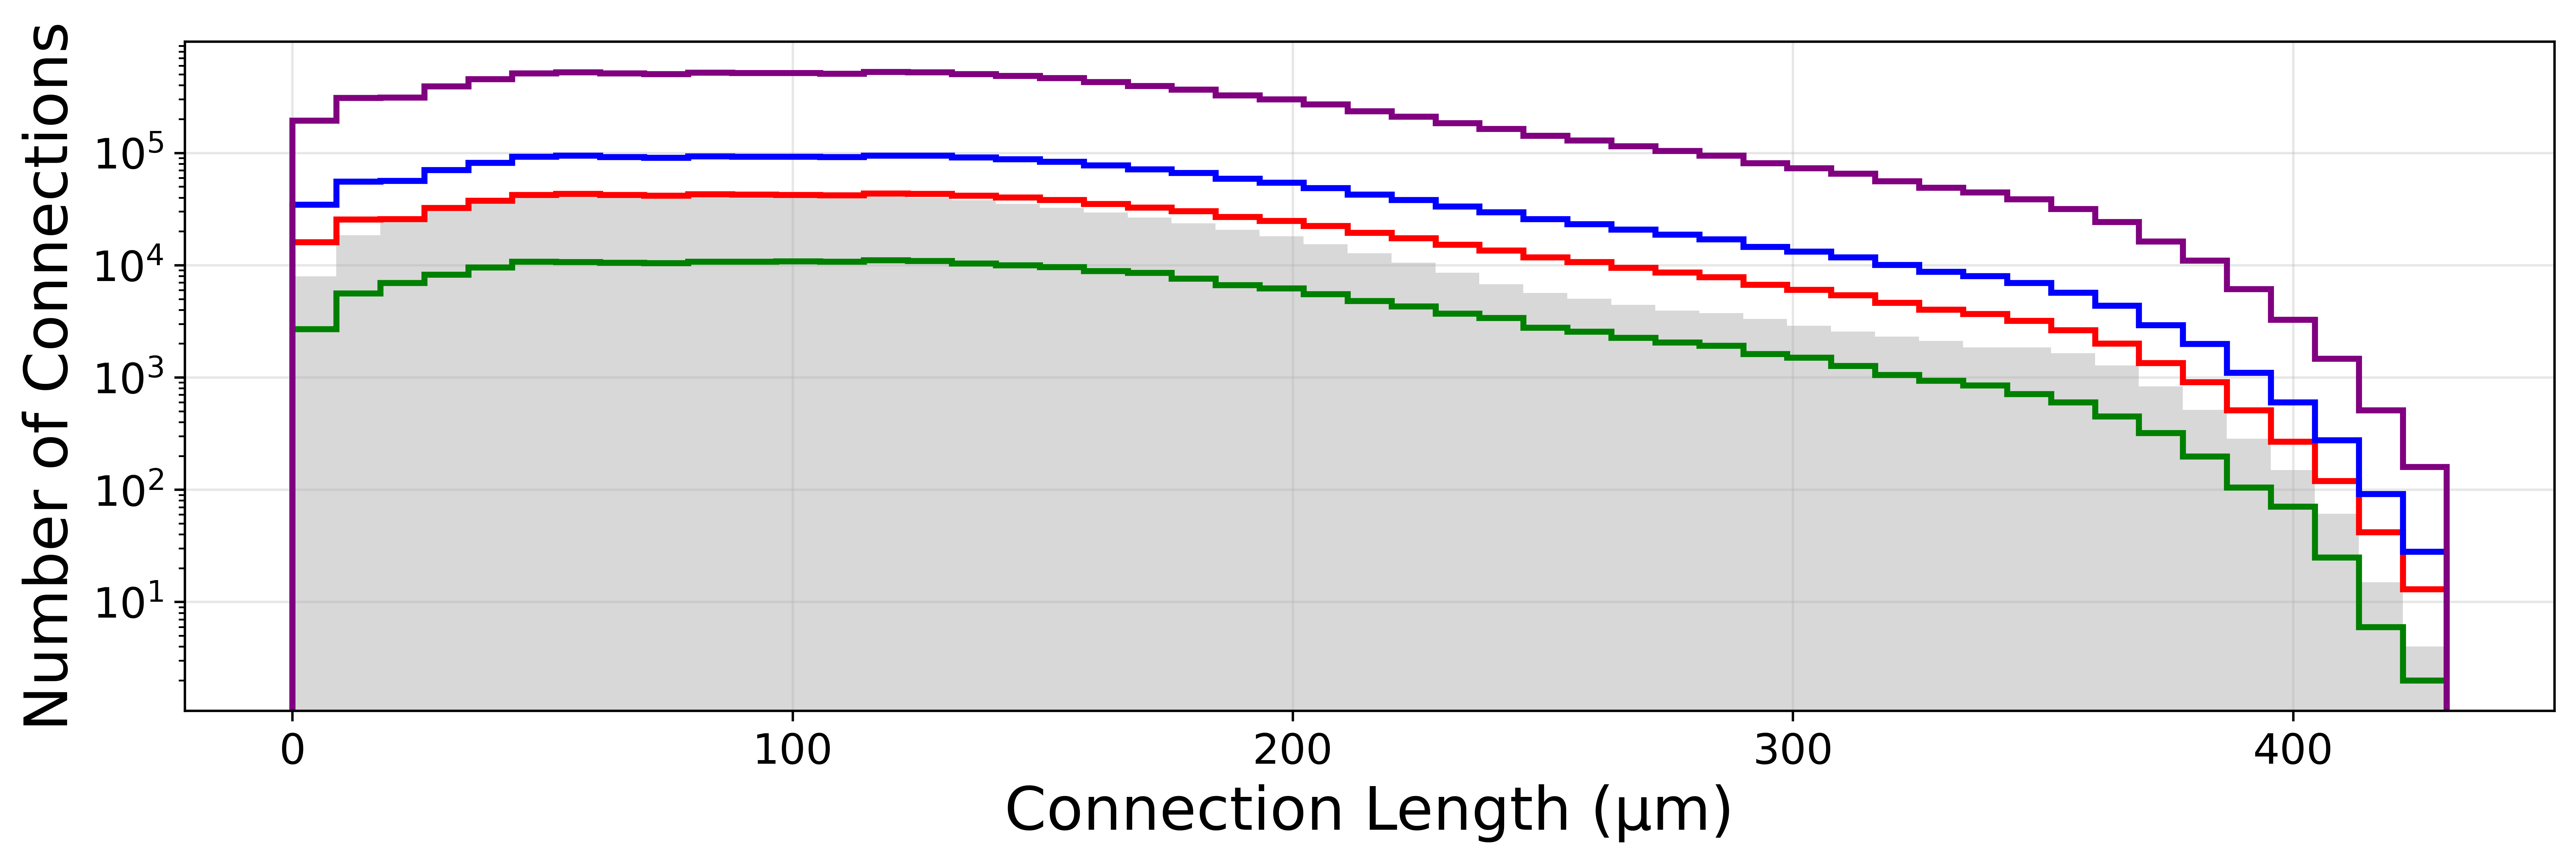

In [19]:
# Plot connection distance distributions with log scale
print("Plotting connection distance distributions with log scale...")
plt.figure(figsize=(12, 4), dpi=600)


# First plot Original Network as filled histogram with grey color and opacity 0.3
original_index = labels.index("Original Network")
original_values = distance_data_um["Original Network"]
plt.hist(
    original_values,
    bins=bins,
    alpha=0.3,
    color='grey',
    label=f"{labels[original_index]}",
    histtype="bar",
    linewidth=1.5
)

for i, label in enumerate(labels):
    if label != "Original Network":  # Skip the Original Network since we already plotted it
        distances_um = distance_data_um[label]
        if distances_um:
            plt.hist(
                distances_um,
                bins=bins,
                alpha=1,
                color=colors[i],
                label=f"{label}",
                histtype="step",  # Fixed: Changed plottype to histtype
                linewidth=2
            )
plt.xlabel('Connection Length (µm)', fontsize=20)  # Updated to show μm instead of Euclidean
plt.ylabel('Number of Connections', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size
plt.yscale('log')
# plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=14)
plt.grid(True, alpha=0.3)
# plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_connection_length_log.pdf', dpi=600)
print("Saved log-scale connection length distribution comparison plot")

In [ ]:
# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    
    # Set linewidth to 1 for original network only, 0 for others
    lw = 1 if label == "Original Network" else 0
    ms = 0 if label == "Original Network" else 4
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        sorted(in_degree_counts.keys()),
        [in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
        marker='.',
        markersize=ms,
        linewidth=lw,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
# plt.title('In-degree Distribution Comparison', fontsize=16)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('plots/bcnm_comparison_in_degree_distribution.pdf')
print("Saved in-degree distribution comparison plot")

In [ ]:
# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(7, 4), dpi=600)

# Then plot the rest as step histograms
for i, label in enumerate(labels):
        in_degrees = [d for n, d in G.in_degree()]
        in_degree_counts = Counter(in_degrees)
        values = clustering_data[label]

        plt.scatter([in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
                    clustering_data[label],
                    color=colors[i],
                    label=f"{label}")

plt.xlabel('In degree', fontsize=20)
plt.ylabel('Clustering', fontsize=20)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.ylim(1, 80000)
plt.legend()
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
# Create a combined scatter plot of degree vs clustering coefficient
print("Creating scatter plot of degree vs clustering coefficient...")

import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import binned_statistic

# Create figure for combined scatter plot
plt.figure(figsize=(8, 6),dpi=600)

# Define markers for each network to differentiate them
markers = ['o', 's', '^', 'D','p']  # circle, square, triangle, diamond

for i, (G, label) in enumerate(zip(graphs, labels)):
    # Calculate total degree for each node
    total_degrees = {node: G.in_degree(node) + G.out_degree(node) for node in G.nodes()}
    
    # Calculate directed clustering for this graph if not already done
    if label not in clustering_data or len(clustering_data[label]) == 0:
        if G.number_of_nodes() > 1000:
            sample_nodes = random.sample(list(G.nodes()), 1000)
            subgraph = G.subgraph(sample_nodes)
            clustering = directed_clustering_coefficient(subgraph)
        else:
            clustering = directed_clustering_coefficient(G)
        clustering_data[label] = clustering
    else:
        clustering = clustering_data[label]
    
    # Get degrees and clustering coefficients
    degrees = []
    cc_values = []
    
    # Sample nodes to avoid overcrowding
    sample_size = min(300, G.number_of_nodes())
    sample_nodes = random.sample(list(G.nodes()), sample_size)
    
    for node in sample_nodes:
        if isinstance(clustering, dict) and node in clustering:
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node])
        elif isinstance(clustering, list) and len(clustering) == G.number_of_nodes():
            node_idx = list(G.nodes()).index(node)
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node_idx])
    
    # Add jitter to reduce exact overlaps
    jitter = np.random.normal(0, 0.01, len(cc_values))
    cc_values_jittered = [max(0, min(1, v + j)) for v, j in zip(cc_values, jitter)]
    
    # Plot the scatter plot
    plt.scatter(
        degrees, 
        cc_values_jittered, 
        alpha=0.4,  # More transparent 
        color=colors[i], 
        marker=markers[i % len(markers)],
        s=30,  # Smaller marker size
        linewidth=0.5,
        label=f"{label}"
    )
    
    # Add trend line using binned statistics
    if len(degrees) > 10:  # Only create trend line if we have enough data points
        # Filter out non-positive degrees for logarithmic binning
        pos_degrees = [d for d in degrees if d > 0]
        if len(pos_degrees) > 10:  # Only create trend line if we have enough positive values
            # Create logarithmic bins
            bins = np.logspace(np.log10(min(pos_degrees)), np.log10(max(pos_degrees)), 10)
            
            # Filter paired data
            pos_indices = [j for j, d in enumerate(degrees) if d > 0]
            filtered_degrees = [degrees[j] for j in pos_indices]
            filtered_cc = [cc_values[j] for j in pos_indices]
            
            bin_means, bin_edges, _ = binned_statistic(filtered_degrees, filtered_cc, statistic='mean', bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Remove NaN values that might appear in some bins
            valid_idx = ~np.isnan(bin_means)
            bin_centers = bin_centers[valid_idx]
            bin_means = bin_means[valid_idx]
            
            # Plot trend line
            plt.plot(
                bin_centers, 
                bin_means, 
                color=colors[i], 
                linewidth=2, 
                label=f"{label} Trend"
            )

# Set plot properties
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel('Total Degree (log scale)', fontsize=20)
plt.ylabel('Directed Clustering Coefficient', fontsize=20)
# plt.title('Degree vs Clustering Coefficient', fontsize=16)
plt.legend(fontsize=12, loc='best')
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size

plt.tight_layout()
plt.savefig('plots/cluster_degree_vs_clustering.png', dpi=600)
print("Saved degree vs clustering visualization at 600dpi")